## Step 1 — Dataset audit and structure validation

In this step, we inspect all river CSV files before modeling.  
The goal is to understand the data structure, verify that the time series are complete, confirm the availability of discharge and rainfall data, and identify missing values or inconsistent columns across rivers.

This audit helps us answer the following questions:

- Do all rivers contain valid daily observations?
- Is discharge available and clean?
- Is rainfall available for all rivers?
- Are the date ranges aligned across files?
- Are there duplicated dates or corrupted records?
- Which columns are reliable enough to keep for modeling?

This step is essential because we do not want to start feature engineering or model training before confirming that the raw data is usable.

In [72]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# =========================
# 1) PATH
# =========================
DATA_DIR = Path(r"C:\Users\omar serhal\Downloads\newdatasetML")
assert DATA_DIR.exists(), f"Folder not found: {DATA_DIR}"

csv_files = sorted(DATA_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if len(csv_files) == 0:
    raise ValueError("No CSV files found in the folder.")

# =========================
# 2) EXPECTED COLUMNS
# =========================
DATE_CANDIDATES = ["date", "Date"]
RIVER_ID_CANDIDATES = ["river_id", "site_site_no", "site_no"]
RIVER_NAME_CANDIDATES = ["river_name", "site_station_nm", "station_name"]

DISCHARGE_CANDIDATES = [
    "usgs_00060_discharge_cubic_feet_per_second",
    "streamflow",
    "discharge",
]

RAIN_CANDIDATES = [
    "usgs_00045_precipitation_total_inches",
    "rainfall",
    "precipitation",
    "weather_precipitation_sum",
    "weather_rain_sum",
]

STATIC_FEATURES_CANDIDATES = [
    "river_drainage_area_sqmi",
    "river_mainstem_length_km",
    "river_elevation_ft",
    "river_gage_datum_ft",
    "river_latitude",
    "river_longitude",
]

# =========================
# 3) HELPERS
# =========================
def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def safe_datetime(series):
    return pd.to_datetime(series, errors="coerce")


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def audit_one_file(path: Path) -> dict:
    try:
        df = pd.read_csv(path)
    except Exception as e:
        return {
            "file_name": path.name,
            "status": f"READ_ERROR: {e}",
            "row_count": np.nan,
            "col_count": np.nan,
        }

    cols = list(df.columns)

    date_col = first_existing_column(df, DATE_CANDIDATES)
    river_id_col = first_existing_column(df, RIVER_ID_CANDIDATES)
    river_name_col = first_existing_column(df, RIVER_NAME_CANDIDATES)
    discharge_col = first_existing_column(df, DISCHARGE_CANDIDATES)
    rain_col = first_existing_column(df, RAIN_CANDIDATES)

    # Basic stats
    row_count = len(df)
    col_count = len(df.columns)

    # Date info
    min_date, max_date, duplicate_dates, unique_dates = None, None, None, None
    if date_col is not None:
        dt = safe_datetime(df[date_col])
        valid_dt = dt.dropna()
        if len(valid_dt) > 0:
            min_date = valid_dt.min()
            max_date = valid_dt.max()
            unique_dates = valid_dt.nunique()
            duplicate_dates = int(valid_dt.duplicated().sum())

    # Missing ratios
    missing_ratio_mean = float(df.isna().mean().mean()) if row_count > 0 else np.nan
    high_missing_cols = int((df.isna().mean() > 0.50).sum())

    # Discharge checks
    has_discharge = discharge_col is not None
    discharge_missing = np.nan
    discharge_neg_count = np.nan
    discharge_zero_count = np.nan
    discharge_max = np.nan
    discharge_mean = np.nan

    if has_discharge:
        q = safe_numeric(df[discharge_col])
        discharge_missing = int(q.isna().sum())
        discharge_neg_count = int((q < 0).sum())
        discharge_zero_count = int((q == 0).sum())
        discharge_max = float(q.max()) if q.notna().any() else np.nan
        discharge_mean = float(q.mean()) if q.notna().any() else np.nan

    # Rain checks
    has_rain = rain_col is not None
    rain_missing = np.nan
    rain_neg_count = np.nan
    rain_zero_count = np.nan
    rain_max = np.nan
    rain_mean = np.nan

    if has_rain:
        r = safe_numeric(df[rain_col])
        rain_missing = int(r.isna().sum())
        rain_neg_count = int((r < 0).sum())
        rain_zero_count = int((r == 0).sum())
        rain_max = float(r.max()) if r.notna().any() else np.nan
        rain_mean = float(r.mean()) if r.notna().any() else np.nan

    # River identity
    river_id_value = None
    if river_id_col is not None and df[river_id_col].notna().any():
        uniq = df[river_id_col].dropna().astype(str).unique()
        river_id_value = uniq[0] if len(uniq) > 0 else None

    river_name_value = None
    if river_name_col is not None and df[river_name_col].notna().any():
        uniq = df[river_name_col].dropna().astype(str).unique()
        river_name_value = uniq[0] if len(uniq) > 0 else None

    # Static features presence
    static_present = [c for c in STATIC_FEATURES_CANDIDATES if c in df.columns]
    static_missing_summary = {
        c: float(df[c].isna().mean()) for c in static_present
    }

    return {
        "file_name": path.name,
        "status": "OK",
        "row_count": row_count,
        "col_count": col_count,
        "river_id_col": river_id_col,
        "river_id_value": river_id_value,
        "river_name_col": river_name_col,
        "river_name_value": river_name_value,
        "date_col": date_col,
        "min_date": min_date,
        "max_date": max_date,
        "unique_dates": unique_dates,
        "duplicate_dates": duplicate_dates,
        "has_discharge": has_discharge,
        "discharge_col": discharge_col,
        "discharge_missing": discharge_missing,
        "discharge_neg_count": discharge_neg_count,
        "discharge_zero_count": discharge_zero_count,
        "discharge_mean": discharge_mean,
        "discharge_max": discharge_max,
        "has_rain": has_rain,
        "rain_col": rain_col,
        "rain_missing": rain_missing,
        "rain_neg_count": rain_neg_count,
        "rain_zero_count": rain_zero_count,
        "rain_mean": rain_mean,
        "rain_max": rain_max,
        "missing_ratio_mean": missing_ratio_mean,
        "high_missing_cols_over_50pct": high_missing_cols,
        "static_features_present": ", ".join(static_present),
        "static_features_missing_ratio": str(static_missing_summary),
    }


# =========================
# 4) RUN AUDIT
# =========================
audit_results = [audit_one_file(p) for p in csv_files]
audit_df = pd.DataFrame(audit_results)

print("\n=== AUDIT SUMMARY TABLE ===")
print(audit_df.head())

# Save summary
summary_path = DATA_DIR / "audit_summary_all_rivers.csv"
audit_df.to_csv(summary_path, index=False)
print(f"\nSaved audit summary to:\n{summary_path}")

# =========================
# 5) GLOBAL SUMMARY
# =========================
print("\n=== GLOBAL SUMMARY ===")
print("Total files:", len(audit_df))
print("Readable files:", (audit_df["status"] == "OK").sum())
print("Files with discharge:", audit_df["has_discharge"].fillna(False).sum())
print("Files with rain:", audit_df["has_rain"].fillna(False).sum())

if "row_count" in audit_df.columns:
    print("Min rows:", audit_df["row_count"].min())
    print("Max rows:", audit_df["row_count"].max())

print("\nFiles with duplicate dates > 0:")
dup_df = audit_df[(audit_df["duplicate_dates"].fillna(0) > 0)]
print(dup_df[["file_name", "river_id_value", "duplicate_dates"]])

print("\nFiles missing discharge:")
miss_q = audit_df[audit_df["has_discharge"] == False]
print(miss_q[["file_name", "river_id_value", "river_name_value"]])

print("\nFiles missing rain:")
miss_r = audit_df[audit_df["has_rain"] == False]
print(miss_r[["file_name", "river_id_value", "river_name_value"]])

print("\nFiles with negative discharge:")
neg_q = audit_df[audit_df["discharge_neg_count"].fillna(0) > 0]
print(neg_q[["file_name", "river_id_value", "discharge_neg_count"]])

print("\nFiles with negative rain:")
neg_r = audit_df[audit_df["rain_neg_count"].fillna(0) > 0]
print(neg_r[["file_name", "river_id_value", "rain_neg_count"]])

print("\nFiles with many highly-missing columns (>50% missing):")
many_missing = audit_df[audit_df["high_missing_cols_over_50pct"].fillna(0) > 10]
print(many_missing[["file_name", "river_id_value", "high_missing_cols_over_50pct"]])

# =========================
# 6) COLUMN INVENTORY
# =========================
all_columns = {}
for p in csv_files:
    try:
        temp = pd.read_csv(p, nrows=5)
        for c in temp.columns:
            all_columns[c] = all_columns.get(c, 0) + 1
    except:
        pass

columns_df = pd.DataFrame(
    [{"column_name": k, "num_files_present": v} for k, v in all_columns.items()]
).sort_values(["num_files_present", "column_name"], ascending=[False, True])

columns_path = DATA_DIR / "audit_columns_inventory.csv"
columns_df.to_csv(columns_path, index=False)

print("\n=== TOP COLUMNS PRESENT ACROSS FILES ===")
print(columns_df.head(50))
print(f"\nSaved columns inventory to:\n{columns_path}")

# =========================
# 7) RECOMMENDED CORE COLUMNS CHECK
# =========================
recommended_core = [
    "river_id",
    "river_name",
    "date",
    "river_drainage_area_sqmi",
    "river_mainstem_length_km",
    "river_elevation_ft",
    "usgs_00045_precipitation_total_inches",
    "usgs_00060_discharge_cubic_feet_per_second",
]

core_presence = []
for p in csv_files:
    try:
        temp = pd.read_csv(p, nrows=3)
        row = {"file_name": p.name}
        for c in recommended_core:
            row[c] = c in temp.columns
        core_presence.append(row)
    except Exception as e:
        core_presence.append({"file_name": p.name, "error": str(e)})

core_df = pd.DataFrame(core_presence)
core_path = DATA_DIR / "audit_core_columns_presence.csv"
core_df.to_csv(core_path, index=False)

print("\n=== CORE COLUMNS PRESENCE ===")
print(core_df.head())
print(f"\nSaved core columns presence to:\n{core_path}")

# =========================
# 8) OPTIONAL: PREVIEW ONE FILE
# =========================
sample_file = csv_files[0]
sample_df = pd.read_csv(sample_file)

print("\n=== SAMPLE FILE ===")
print("File:", sample_file.name)
print("Shape:", sample_df.shape)
print("Columns:")
print(sample_df.columns.tolist())

print("\nFirst 5 rows:")
print(sample_df.head())

CSV files found: 68

=== AUDIT SUMMARY TABLE ===
      file_name status  row_count  col_count river_id_col river_id_value river_name_col river_name_value date_col   min_date   max_date  unique_dates  duplicate_dates  has_discharge  \
0  01434000.csv     OK       4018         71     river_id        1434000     river_name         River 18     date 2014-01-01 2024-12-31        4018.0              0.0           True   
1  01435000.csv     OK       4018         90     river_id        1435000     river_name         River 19     date 2014-01-01 2024-12-31        4018.0              0.0           True   
2  01439500.csv     OK       4018         68     river_id        1439500     river_name          River 2     date 2014-01-01 2024-12-31        4018.0              0.0           True   
3  01440400.csv     OK       4018         84     river_id        1440400     river_name         River 20     date 2014-01-01 2024-12-31        4018.0              0.0           True   
4  01451800.csv     OK    

## Step 2 — Select the core hydrologic and basin variables

The raw files contain many columns, but not all of them are equally useful for the flood prediction task.

At this stage, we keep only the variables that are most relevant for hydrologic modeling:

- river identifiers
- date
- discharge
- precipitation
- basin characteristics such as drainage area, river length, and elevation
- selected weather variables when available

This simplifies the dataset and prevents noisy or highly incomplete columns from interfering with the next steps.

In [73]:
audit_df["type"] = "GOOD"

audit_df.loc[audit_df["has_rain"] == False, "type"] = "NO_RAIN"

audit_df.loc[
    (audit_df["has_rain"] == True) &
    (audit_df["missing_ratio_mean"] > 0.25),
    "type"
] = "HIGH_MISSING"

audit_df["type"].value_counts()

type
NO_RAIN         31
GOOD            21
HIGH_MISSING    16
Name: count, dtype: int64

In [74]:
good_rivers = audit_df[audit_df["type"] == "GOOD"]["river_id_value"]

print(len(good_rivers))
print(good_rivers.tolist())

21
['1434000', '1439500', '1463500', '1464500', '1474000', '1481000', '1487000', '1488500', '1493500', '1503000', '1516500', '1520000', '1531000', '1536000', '1539000', '1540500', '1544000', '1544000', '3070500', 'True', '1434000']


## Step 2 — Merge only the selected high-quality river files

In this step, we load and merge only the river CSV files that passed the initial audit and were classified as `GOOD`.

The purpose of this step is to:
- exclude rivers with no rainfall data
- exclude rivers with high missingness
- keep only the most reliable rivers for downstream hydrologic analysis and flood modeling

We read each CSV file, check that it contains a valid `river_id`, and keep it only if that `river_id` belongs to the list of selected good rivers.

Finally, we concatenate all selected river datasets into one combined dataframe called `full_df`.

In [75]:
from pathlib import Path
import pandas as pd

# =========================================
# Step — Load files
# =========================================
DATA_DIR = Path(r"C:\Users\omar serhal\Downloads\newdatasetML")
csv_files = sorted(DATA_DIR.glob("*.csv"))

# =========================================
# Step — Clean GOOD river ids safely
#
# =========================================
good_rivers = (
    audit_df.loc[audit_df["type"] == "GOOD", "river_id_value"]
    .pipe(pd.to_numeric, errors="coerce")   # convert safely
    .dropna()                               # remove bad values
    .astype(int)
)

good_rivers_set = set(good_rivers)

print("Valid GOOD rivers:", len(good_rivers_set))

# =========================================
# Step — Load and filter CSVs
# =========================================
dfs = []

for p in csv_files:
    try:
        df = pd.read_csv(p)

        # skip if missing river_id
        if "river_id" not in df.columns:
            continue

        # convert river_id safely
        river_id = pd.to_numeric(df["river_id"].iloc[0], errors="coerce")

        if pd.isna(river_id):
            continue

        river_id = int(river_id)

        # keep only GOOD rivers
        if river_id in good_rivers_set:
            dfs.append(df)

    except Exception as e:
        print(f"Error in file {p.name}: {e}")

print("Number of selected files:", len(dfs))

# =========================================
# Step — Merge
# =========================================
full_df = pd.concat(dfs, ignore_index=True)

print("Merged dataframe shape:", full_df.shape)
print("Number of rivers:", full_df["river_id"].nunique())

full_df.head(100)

Valid GOOD rivers: 18
Number of selected files: 25
Merged dataframe shape: (285931, 150)
Number of rivers: 18


,river_id,river_name,date,river_latitude,river_longitude,river_drainage_area_sqmi,river_contrib_drainage_area_sqmi,river_elevation_ft,river_gage_datum_ft,river_mainstem_length_km,usgs_00010_temperature_water_degrees_celsius_x,usgs_00010_temperature_water_degrees_celsius_y,usgs_00010_temperature_water_degrees_celsius,usgs_00060_discharge_cubic_feet_per_second,usgs_00095_specific_conductance_water_unfiltered_microsiemens_per_centimeter_at_25_degrees_celsius_x,usgs_00095_specific_conductance_water_unfiltered_microsiemens_per_centimeter_at_25_degrees_celsius_y,usgs_00095_specific_conductance_water_unfiltered_microsiemens_per_centimeter_at_25_degrees_celsius,weather_weather_code,weather_temperature_2m_max,weather_temperature_2m_min,weather_temperature_2m_mean,weather_apparent_temperature_max,weather_apparent_temperature_min,weather_apparent_temperature_mean,weather_precipitation_sum,weather_rain_sum,weather_snowfall_sum,weather_precipitation_hours,weather_wind_speed_10m_max,weather_wind_gusts_10m_max,weather_wind_direction_10m_dominant,weather_shortwave_radiation_sum,weather_et0_fao_evapotranspiration,weather_relative_humidity_2m_mean,weather_relative_humidity_2m_max,weather_relative_humidity_2m_min,weather_surface_pressure_mean,site_source,weather_source,feature_window_start,feature_window_end,site_agency_cd,site_site_no,site_station_nm,site_site_tp_cd,site_lat_va,site_long_va,site_dec_lat_va,site_dec_long_va,site_coord_meth_cd,site_coord_acy_cd,site_coord_datum_cd,site_dec_coord_datum_cd,site_district_cd,site_state_cd,site_county_cd,site_country_cd,site_map_nm,site_map_scale_fc,site_alt_va,site_alt_meth_cd,site_alt_acy_va,site_alt_datum_cd,site_huc_cd,site_instruments_cd,site_inventory_dt,site_drain_area_va,site_tz_cd,site_local_time_fg,site_gw_file_cd,nldi_comid,usgs_00300_dissolved_oxygen_water_unfiltered_milligrams_per_liter_x,usgs_00300_dissolved_oxygen_water_unfiltered_milligrams_per_liter_y,usgs_00300_dissolved_oxygen_water_unfiltered_milligrams_per_liter,usgs_00301_dissolved_oxygen_water_unfiltered_percent_of_saturation_x,usgs_00301_dissolved_oxygen_water_unfiltered_percent_of_saturation_y,usgs_00301_dissolved_oxygen_water_unfiltered_percent_of_saturation,usgs_00400_ph_water_unfiltered_field_standard_units_x,usgs_00400_ph_water_unfiltered_field_standard_units_y,usgs_00400_ph_water_unfiltered_field_standard_units,usgs_32318_chlorophylls_water_in_situ_fluorometric_method_excitation_at_470_15_nm_emission_at_685_20_nm_micrograms_per_liter_x,usgs_32318_chlorophylls_water_in_situ_fluorometric_method_excitation_at_470_15_nm_emission_at_685_20_nm_micrograms_per_liter_y,usgs_32318_chlorophylls_water_in_situ_fluorometric_method_excitation_at_470_15_nm_emission_at_685_20_nm_micrograms_per_liter,usgs_63680_turbidity_water_unfiltered_monochrome_near_infra_red_led_light_780_900_nm_detection_angle_90_2_5_degrees_formazin_nephelometric_units_fnu_x,usgs_63680_turbidity_water_unfiltered_monochrome_near_infra_red_led_light_780_900_nm_detection_angle_90_2_5_degrees_formazin_nephelometric_units_fnu_y,usgs_63680_turbidity_water_unfiltered_monochrome_near_infra_red_led_light_780_900_nm_detection_angle_90_2_5_degrees_formazin_nephelometric_units_fnu,usgs_99133_nitrate_plus_nitrite_water_in_situ_milligrams_per_liter_as_nitrogen_x,usgs_99133_nitrate_plus_nitrite_water_in_situ_milligrams_per_liter_as_nitrogen_y,usgs_99133_nitrate_plus_nitrite_water_in_situ_milligrams_per_liter_as_nitrogen,site_land_net_ds,usgs_00045_precipitation_total_inches,usgs_70387_chloride_water_unfiltered_computed_by_regression_equation_milligrams_per_liter,site_project_no,site_contrib_drain_area_va,site_topo_cd,streamflow,rainfall,target_date,horizon_day,pred_flow,capacity_q95,true_flow,is_flood,rain_3d,rain_7d,rain_14d,flow_lag1,flow_lag2,flow_lag3,flow_3d_avg,flow_7d_avg,flow_14d_avg,flow_ratio_q95,flow_lag1_ratio,rain_per_area,rain_flow_ratio,flow_spike,pred_prob_flood,pred_class,flow,rain,flow_norm,capacity_q90_x,capacity_q95_y,capacity_q98_x,capacity_q90_y,capacity_q98_

In [58]:
print(full_df["is_flood"].isna().mean())

0.8312215184782342


In [68]:
# =========================================================
# CHECK is_flood WITHOUT MODIFYING full_df
# =========================================================

print("Original full_df shape:", full_df.shape)

print("\nis_flood NaN ratio:")
print(full_df["is_flood"].isna().mean())

print("\nis_flood counts including NaN:")
print(full_df["is_flood"].value_counts(dropna=False))

# =========================================================
# CREATE CLASSIFICATION DATA ONLY FROM LABELED ROWS
# full_df stays unchanged
# =========================================================

cls_label_df = full_df[full_df["is_flood"].notna()].copy()
cls_label_df["is_flood"] = cls_label_df["is_flood"].astype(int)

print("\nfull_df shape after filtering check:", full_df.shape)
print("Classification labeled df shape:", cls_label_df.shape)

print("\nClassification label distribution:")
print(cls_label_df["is_flood"].value_counts())
print(cls_label_df["is_flood"].value_counts(normalize=True))

print("\nPer river flood rate inside labeled rows:")
print(cls_label_df.groupby("river_id")["is_flood"].mean().sort_values(ascending=False))

Original full_df shape: (285931, 150)

is_flood NaN ratio:
0.8312215184782342

is_flood counts including NaN:
is_flood
NaN    237672
0.0     45805
1.0      2454
Name: count, dtype: int64

full_df shape after filtering check: (285931, 150)
Classification labeled df shape: (48259, 150)

Classification label distribution:
is_flood
0    45805
1     2454
Name: count, dtype: int64
is_flood
0    0.949149
1    0.050851
Name: proportion, dtype: float64

Per river flood rate inside labeled rows:
river_id
1487000    0.068094
1536000    0.065286
1463500    0.063882
1434000    0.062478
1503000    0.057564
1540500    0.057564
1539000    0.051948
1544000    0.047834
1516500    0.046771
1488500    0.045630
1481000    0.045630
1531000    0.045630
1520000    0.044224
1439500    0.043524
1474000    0.042120
1464500    0.041418
1493500    0.034398
Name: is_flood, dtype: float64


## Step 3 — Create a unified rainfall variable

Rainfall is not stored consistently across all rivers.  
Some rivers use USGS precipitation, while others use weather-based precipitation.

To standardize the dataset, we create a single column `rain` by prioritizing:
1. USGS precipitation when available
2. Weather precipitation otherwise

This ensures all rivers use the same rainfall representation.

In [76]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# =========================================================
# 1) KEEP full_df COMPLETE
# =========================================================
full_df = full_df.loc[:, ~full_df.columns.duplicated()].copy()

# =========================================================
# 2) UNIFY RAIN SAFELY
# =========================================================
rain_sources = [
    "usgs_00045_precipitation_total_inches",
    "weather_precipitation_sum",
    "rain"
]

existing_rain_sources = [c for c in rain_sources if c in full_df.columns]

if len(existing_rain_sources) == 0:
    raise ValueError("No rain source columns found.")

full_df["rain"] = full_df[existing_rain_sources].bfill(axis=1).iloc[:, 0]

print("Rain NaN count:", full_df["rain"].isna().sum())
print(full_df[["rain"]].describe())

# =========================================================
# 3) CREATE CLASSIFICATION DATA ONLY FROM REAL LABELS
# full_df stays unchanged
# =========================================================
if "is_flood" not in full_df.columns:
    raise ValueError("is_flood column missing.")

cls_label_df = full_df[full_df["is_flood"].notna()].copy()
cls_label_df["is_flood"] = cls_label_df["is_flood"].astype(int)

print("\nClassification labeled rows:", cls_label_df.shape)
print(cls_label_df["is_flood"].value_counts())
print(cls_label_df["is_flood"].value_counts(normalize=True))

# =========================================================
# 4) FIX DATE ONLY IF POSSIBLE
# =========================================================
if "date" in cls_label_df.columns:
    cls_label_df["date"] = pd.to_datetime(cls_label_df["date"], errors="coerce")
else:
    cls_label_df["date"] = pd.NaT

date_nan_ratio = cls_label_df["date"].isna().mean()

print("\nDate NaN ratio in labeled rows:", date_nan_ratio)
print("Date min/max:", cls_label_df["date"].min(), cls_label_df["date"].max())

# =========================================================
# 5) SPLIT
# Prefer time split if enough labeled dates exist.
# Otherwise use stratified split.
# =========================================================

if date_nan_ratio < 0.50:
    # use only rows with valid date for time split
    cls_label_dated = cls_label_df[cls_label_df["date"].notna()].copy()
    cls_label_dated = cls_label_dated.sort_values("date").copy()

    cls_train = cls_label_dated[cls_label_dated["date"] < "2022-01-01"].copy()
    cls_test  = cls_label_dated[cls_label_dated["date"] >= "2022-01-01"].copy()

    # fallback if 2022 split fails
    if len(cls_train) == 0 or len(cls_test) == 0 or cls_train["is_flood"].nunique() < 2 or cls_test["is_flood"].nunique() < 2:
        print("\nTime split failed. Falling back to chronological 80/20 split.")
        split_point = int(len(cls_label_dated) * 0.80)
        cls_train = cls_label_dated.iloc[:split_point].copy()
        cls_test  = cls_label_dated.iloc[split_point:].copy()

        # if still bad, stratify
        if cls_train["is_flood"].nunique() < 2 or cls_test["is_flood"].nunique() < 2:
            print("Chronological split has one class. Falling back to stratified split.")
            cls_train, cls_test = train_test_split(
                cls_label_df,
                test_size=0.2,
                stratify=cls_label_df["is_flood"],
                random_state=42
            )
else:
    print("\nToo many missing dates in labeled rows. Using stratified split.")
    cls_train, cls_test = train_test_split(
        cls_label_df,
        test_size=0.2,
        stratify=cls_label_df["is_flood"],
        random_state=42
    )

# =========================================================
# 6) CHECK SPLIT
# =========================================================
print("\nClassifier train:", cls_train.shape)
print("Classifier test :", cls_test.shape)

print("\nTrain dates:", cls_train["date"].min(), cls_train["date"].max())
print("Test dates :", cls_test["date"].min(), cls_test["date"].max())

print("\nTrain labels:")
print(cls_train["is_flood"].value_counts())
print(cls_train["is_flood"].value_counts(normalize=True))

print("\nTest labels:")
print(cls_test["is_flood"].value_counts())
print(cls_test["is_flood"].value_counts(normalize=True))

Rain NaN count: 141754
                rain
count  144177.000000
mean        3.103644
std         6.917054
min         0.000000
25%         0.000000
50%         0.200000
75%         2.800000
max       148.200000

Classification labeled rows: (48259, 150)
is_flood
0    45805
1     2454
Name: count, dtype: int64
is_flood
0    0.949149
1    0.050851
Name: proportion, dtype: float64

Date NaN ratio in labeled rows: 1.0
Date min/max: NaT NaT

Too many missing dates in labeled rows. Using stratified split.

Classifier train: (38607, 150)
Classifier test : (9652, 150)

Train dates: NaT NaT
Test dates : NaT NaT

Train labels:
is_flood
0    36644
1     1963
Name: count, dtype: int64
is_flood
0    0.949154
1    0.050846
Name: proportion, dtype: float64

Test labels:
is_flood
0    9161
1     491
Name: count, dtype: int64
is_flood
0    0.94913
1    0.05087
Name: proportion, dtype: float64


## Flood Classification Model — Final Safety-Oriented Setup

In this part, we built a flood classification model using only the rows that contain real `is_flood` labels.  
The original dataset was kept unchanged; rows with missing `is_flood` were excluded only from the classification training/evaluation step.

Because flood prediction is a safety-critical problem, the model was optimized to reduce missed floods as much as possible.  
Therefore, recall was prioritized over precision, since failing to detect a real flood is more dangerous than producing a false alarm.

A Random Forest classifier was trained using selected rainfall, flow-lag, rolling-flow, seasonal, and static river features.  
Cross-validation and hyperparameter tuning were applied to improve robustness.  
After training, probability threshold tuning was performed to choose a safer operating point.

The selected threshold was:

```text
Threshold = 0.30

In [80]:
cls_label_df["date"] = pd.to_datetime(cls_label_df["date"])
cls_train = cls_label_df[cls_label_df["date"] < "2022-01-01"].copy()
cls_test  = cls_label_df[cls_label_df["date"] >= "2022-01-01"].copy()
cls_label_df["date"] = pd.to_datetime(cls_label_df["date"])

print(cls_label_df["date"].min())
print(cls_label_df["date"].max())
print(cls_label_df["date"].dt.year.value_counts().sort_index())
print(cls_label_df["is_flood"].value_counts())
cls_label_df = cls_label_df.sort_values("date").copy()

split_point = int(len(cls_label_df) * 0.80)

cls_train = cls_label_df.iloc[:split_point].copy()
cls_test  = cls_label_df.iloc[split_point:].copy()

print("Classifier train:", cls_train.shape)
print("Classifier test :", cls_test.shape)

print("Train dates:", cls_train["date"].min(), cls_train["date"].max())
print("Test dates :", cls_test["date"].min(), cls_test["date"].max())

print("Train labels:")
print(cls_train["is_flood"].value_counts())

print("Test labels:")
print(cls_test["is_flood"].value_counts())

NaT
NaT
Series([], Name: count, dtype: int64)
is_flood
0    45805
1     2454
Name: count, dtype: int64
Classifier train: (38607, 150)
Classifier test : (9652, 150)
Train dates: NaT NaT
Test dates : NaT NaT
Train labels:
is_flood
0    36801
1     1806
Name: count, dtype: int64
Test labels:
is_flood
0    9004
1     648
Name: count, dtype: int64


In [49]:
print(cls_label_df.columns.tolist())

['river_id', 'river_name', 'date', 'river_latitude', 'river_longitude', 'river_drainage_area_sqmi', 'river_contrib_drainage_area_sqmi', 'river_elevation_ft', 'river_gage_datum_ft', 'river_mainstem_length_km', 'usgs_00010_temperature_water_degrees_celsius_x', 'usgs_00010_temperature_water_degrees_celsius_y', 'usgs_00010_temperature_water_degrees_celsius', 'usgs_00060_discharge_cubic_feet_per_second', 'usgs_00095_specific_conductance_water_unfiltered_microsiemens_per_centimeter_at_25_degrees_celsius_x', 'usgs_00095_specific_conductance_water_unfiltered_microsiemens_per_centimeter_at_25_degrees_celsius_y', 'usgs_00095_specific_conductance_water_unfiltered_microsiemens_per_centimeter_at_25_degrees_celsius', 'weather_weather_code', 'weather_temperature_2m_max', 'weather_temperature_2m_min', 'weather_temperature_2m_mean', 'weather_apparent_temperature_max', 'weather_apparent_temperature_min', 'weather_apparent_temperature_mean', 'weather_precipitation_sum', 'weather_rain_sum', 'weather_snowf

In [ ]:

full_df["date"] = pd.to_datetime(full_df["date"], errors="coerce")

cls_label_df = full_df[full_df["is_flood"].notna()].copy()
cls_label_df["is_flood"] = cls_label_df["is_flood"].astype(int)

print(cls_label_df["date"].min(), cls_label_df["date"].max())
print("NaN ratio:", cls_label_df["date"].isna().mean())

NaT NaT
NaN ratio: 1.0


In [63]:
print(full_df["date"].head(20))
print(full_df["date"].dtype)
print(full_df["date"].isna().mean())

0     2014-01-01
1     2014-01-02
2     2014-01-03
3     2014-01-04
4     2014-01-05
5     2014-01-06
6     2014-01-07
7     2014-01-08
8     2014-01-09
9     2014-01-10
10    2014-01-11
11    2014-01-12
12    2014-01-13
13    2014-01-14
14    2014-01-15
15    2014-01-16
16    2014-01-17
17    2014-01-18
18    2014-01-19
19    2014-01-20
Name: date, dtype: object
object
0.4676617785409767


Train counts:
is_flood
0    36801
1     1806
Name: count, dtype: int64

Test counts:
is_flood
0    9004
1     648
Name: count, dtype: int64

Chosen threshold:
threshold    0.840000
precision    0.885329
recall       0.810185
f1           0.846092
Name: 79, dtype: float64

=== FINAL CLEAN CLASSIFICATION RESULTS ===
Threshold: 0.8400000000000002
Precision: 0.8853288364249579
Recall   : 0.8101851851851852
F1       : 0.8460918614020951
ROC-AUC  : 0.9956507670116437

Confusion Matrix:
[[8936   68]
 [ 123  525]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9004
           1       0.89      0.81      0.85       648

    accuracy                           0.98      9652
   macro avg       0.94      0.90      0.92      9652
weighted avg       0.98      0.98      0.98      9652


Top features:
                     feature  importance
10                   rain_3d    0.157534
11                   rain_7d    0.150830

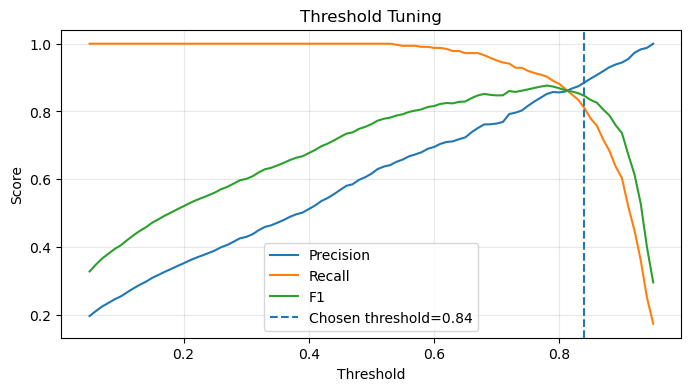

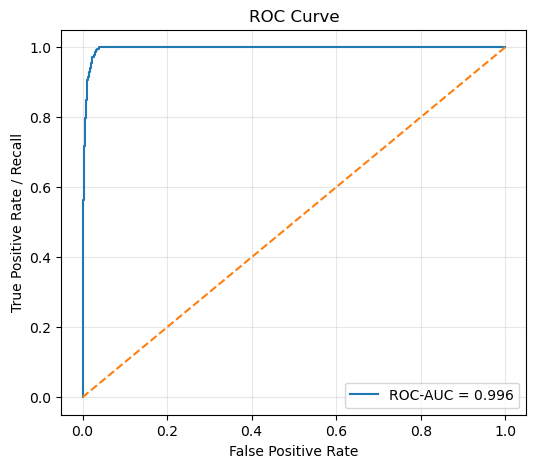

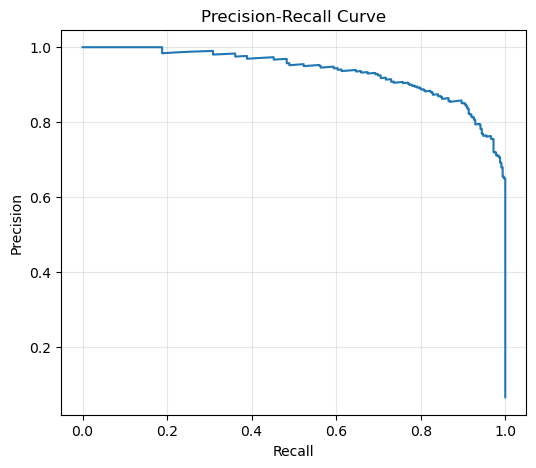

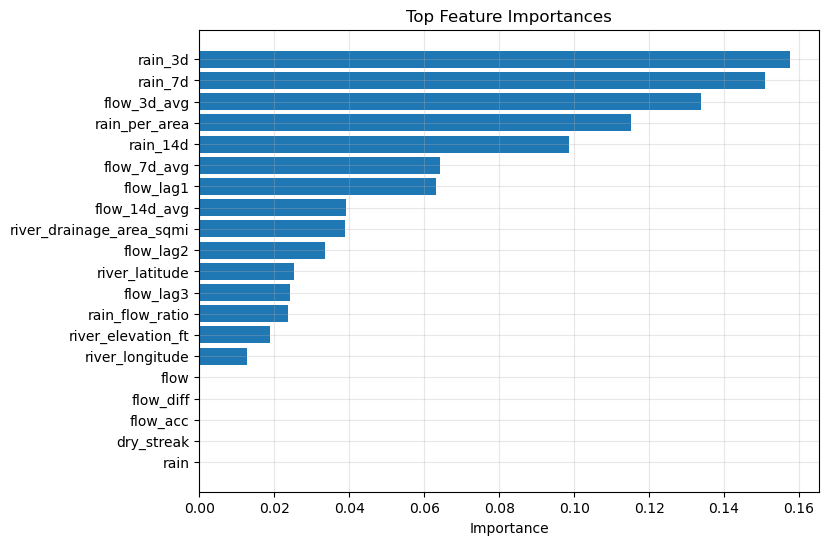


Saved:
- clean_is_flood_classifier.pkl
- clean_is_flood_threshold_tuning.csv
- clean_is_flood_feature_importance.csv
- clean_is_flood_test_predictions.csv
- clean_is_flood_summary.csv

Summary:
   threshold  precision    recall        f1   roc_auc  train_rows  test_rows  n_features
0       0.84   0.885329  0.810185  0.846092  0.995651       38607       9652          25


In [83]:
# =========================================================
# TRAIN CLEAN CLASSIFIER + METRICS PLOTS
# Classification only on rows where is_flood is NOT NaN
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

X_train = cls_train[cls_features].copy()
X_test  = cls_test[cls_features].copy()

# fill NaN using train medians only
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

y_train = cls_train["is_flood"].astype(int)
y_test  = cls_test["is_flood"].astype(int)

print("Train counts:")
print(y_train.value_counts())

print("\nTest counts:")
print(y_test.value_counts())

# important safety checks
if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("Train or test set is empty.")

if y_train.nunique() < 2:
    raise ValueError("Training labels have only one class. Need both 0 and 1.")

if y_test.nunique() < 2:
    print("WARNING: Test labels have only one class. ROC-AUC may fail.")

# =========================================================
# RANDOM FOREST CLASSIFIER
# no compute_class_weight manually
# =========================================================

clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

# probabilities
y_prob = clf.predict_proba(X_test)[:, 1]

# =========================================================
# THRESHOLD TUNING FOR SAFETY
# =========================================================

threshold_rows = []

for thr in np.arange(0.05, 0.96, 0.01):
    y_pred_thr = (y_prob >= thr).astype(int)

    threshold_rows.append({
        "threshold": thr,
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1": f1_score(y_test, y_pred_thr, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)

RECALL_TARGET = 0.80

safe_options = threshold_df[threshold_df["recall"] >= RECALL_TARGET].copy()

if len(safe_options) > 0:
    chosen_row = safe_options.sort_values(["precision", "f1"], ascending=False).iloc[0]
else:
    chosen_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

best_thr = float(chosen_row["threshold"])

print("\nChosen threshold:")
print(chosen_row)

y_pred = (y_prob >= best_thr).astype(int)

# =========================================================
# FINAL METRICS
# =========================================================

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

try:
    roc_auc = roc_auc_score(y_test, y_prob)
except Exception:
    roc_auc = np.nan

print("\n=== FINAL CLEAN CLASSIFICATION RESULTS ===")
print("Threshold:", best_thr)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)
print("ROC-AUC  :", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

feature_importance_df = pd.DataFrame({
    "feature": cls_features,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop features:")
print(feature_importance_df.head(20))

# =========================================================
# PLOTS: PRECISION / RECALL / F1 THRESHOLD
# =========================================================

plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_thr, linestyle="--", label=f"Chosen threshold={best_thr:.2f}")
plt.title("Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# PLOT: ROC CURVE
# =========================================================

if y_test.nunique() == 2:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_curve = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_curve:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# =========================================================
# PLOT: PRECISION-RECALL CURVE
# =========================================================

pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(pr_recall, pr_precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# PLOT: FEATURE IMPORTANCE
# =========================================================

top_n = min(20, len(feature_importance_df))

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance_df.head(top_n)["feature"][::-1],
    feature_importance_df.head(top_n)["importance"][::-1]
)
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================

joblib.dump(clf, "clean_is_flood_classifier.pkl")
threshold_df.to_csv("clean_is_flood_threshold_tuning.csv", index=False)
feature_importance_df.to_csv("clean_is_flood_feature_importance.csv", index=False)

cls_test_out = cls_test.copy()
cls_test_out["flood_prob"] = y_prob
cls_test_out["flood_pred"] = y_pred
cls_test_out.to_csv("clean_is_flood_test_predictions.csv", index=False)

summary_df = pd.DataFrame([{
    "threshold": best_thr,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": roc_auc,
    "train_rows": len(cls_train),
    "test_rows": len(cls_test),
    "n_features": len(cls_features)
}])

summary_df.to_csv("clean_is_flood_summary.csv", index=False)

print("\nSaved:")
print("- clean_is_flood_classifier.pkl")
print("- clean_is_flood_threshold_tuning.csv")
print("- clean_is_flood_feature_importance.csv")
print("- clean_is_flood_test_predictions.csv")
print("- clean_is_flood_summary.csv")

print("\nSummary:")
print(summary_df)

X: (48259, 25)
y distribution:
is_flood
0    0.949149
1    0.050851
Name: proportion, dtype: float64
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': None}
Best CV F1: 0.9356451812576407

CV ROC-AUC: 0.9992455438334095

Best F1 threshold:
threshold    0.600000
precision    0.949819
recall       0.964140
f1           0.956926
Name: 59, dtype: float64

Safety threshold:
threshold    0.710000
precision    0.980514
recall       0.902200
f1           0.939728
Name: 70, dtype: float64

=== CV FINAL RESULTS ===
Threshold: 0.7100000000000001
Precision: 0.9805137289636847
Recall   : 0.902200488997555
F1       : 0.9397283531409168
ROC-AUC  : 0.9992455438334095

Confusion Matrix:
[[45761    44]
 [  240  2214]]

Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     45805
           1       0.98      0.90      

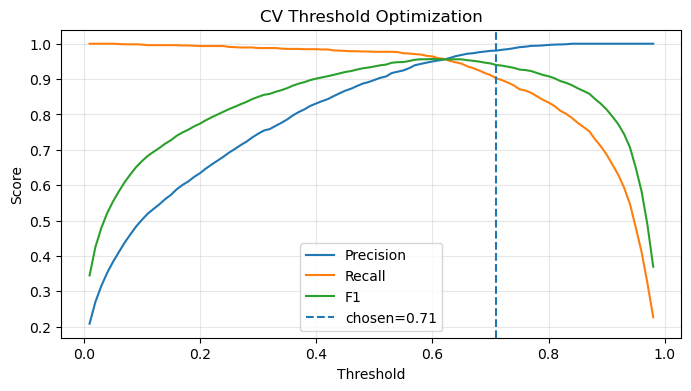

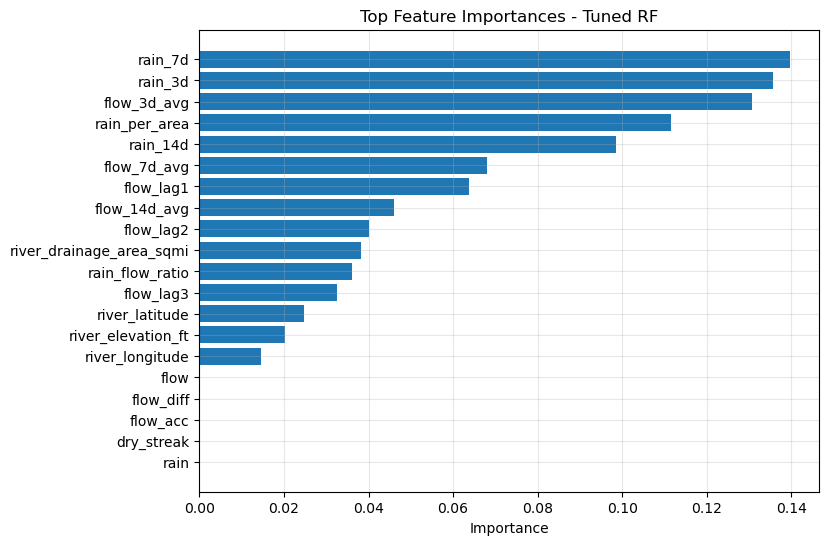


Top features:
                     feature  importance
11                   rain_7d    0.139614
10                   rain_3d    0.135668
4                flow_3d_avg    0.130772
14             rain_per_area    0.111523
12                  rain_14d    0.098408
5                flow_7d_avg    0.067921
1                  flow_lag1    0.063647
6               flow_14d_avg    0.046011
2                  flow_lag2    0.040169
21  river_drainage_area_sqmi    0.038263
15           rain_flow_ratio    0.036069
3                  flow_lag3    0.032514
23            river_latitude    0.024632
22        river_elevation_ft    0.020179
24           river_longitude    0.014611
0                       flow    0.000000
7                  flow_diff    0.000000
8                   flow_acc    0.000000
16                dry_streak    0.000000
9                       rain    0.000000

Saved final tuned classifier.
   chosen_threshold  precision  recall        f1   roc_auc  best_cv_f1_search  n_rows  n_feat

In [88]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# ===============================
# DATA
# ===============================
X = cls_label_df[cls_features].copy()
y = cls_label_df["is_flood"].astype(int)

train_medians = X.median(numeric_only=True)
X = X.fillna(train_medians)

print("X:", X.shape)
print("y distribution:")
print(y.value_counts(normalize=True))

# ===============================
# CV + HYPERPARAMETER SEARCH
# ===============================
base_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [5, 8, 10, 12, None],
    "min_samples_split": [10, 20, 40],
    "min_samples_leaf": [3, 5, 8, 12],
    "max_features": ["sqrt", "log2", 0.5],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X, y)

print("\nBest params:")
print(search.best_params_)
print("Best CV F1:", search.best_score_)

best_rf = search.best_estimator_

# ===============================
# CROSS-VALIDATED PROBABILITIES
# ===============================
cv_probs = cross_val_predict(
    best_rf,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("\nCV ROC-AUC:", roc_auc_score(y, cv_probs))

# ===============================
# THRESHOLD OPTIMIZATION
# ===============================
threshold_rows = []

for thr in np.arange(0.01, 0.99, 0.01):
    pred = (cv_probs >= thr).astype(int)

    threshold_rows.append({
        "threshold": thr,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)

# option 1: best F1
best_f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

# option 2: safety threshold = recall >= 0.90, best precision
RECALL_TARGET = 0.90
safe_options = threshold_df[threshold_df["recall"] >= RECALL_TARGET]

if len(safe_options) > 0:
    safety_row = safe_options.sort_values(["precision", "f1"], ascending=False).iloc[0]
else:
    safety_row = best_f1_row

print("\nBest F1 threshold:")
print(best_f1_row)

print("\nSafety threshold:")
print(safety_row)

chosen_thr = float(safety_row["threshold"])

cv_pred = (cv_probs >= chosen_thr).astype(int)

print("\n=== CV FINAL RESULTS ===")
print("Threshold:", chosen_thr)
print("Precision:", precision_score(y, cv_pred, zero_division=0))
print("Recall   :", recall_score(y, cv_pred, zero_division=0))
print("F1       :", f1_score(y, cv_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y, cv_probs))
print("\nConfusion Matrix:")
print(confusion_matrix(y, cv_pred))
print("\nReport:")
print(classification_report(y, cv_pred, zero_division=0))

# ===============================
# PLOTS
# ===============================
plt.figure(figsize=(8,4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(chosen_thr, linestyle="--", label=f"chosen={chosen_thr:.2f}")
plt.title("CV Threshold Optimization")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

feature_importance_df = pd.DataFrame({
    "feature": cls_features,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_df.head(20)["feature"][::-1],
    feature_importance_df.head(20)["importance"][::-1]
)
plt.title("Top Feature Importances - Tuned RF")
plt.xlabel("Importance")
plt.grid(True, alpha=0.3)
plt.show()

print("\nTop features:")
print(feature_importance_df.head(20))

# ===============================
# SAVE FINAL MODEL
# ===============================
best_rf.fit(X, y)

joblib.dump(best_rf, "tuned_cv_is_flood_classifier.pkl")
threshold_df.to_csv("tuned_cv_thresholds.csv", index=False)
feature_importance_df.to_csv("tuned_cv_feature_importance.csv", index=False)

summary_df = pd.DataFrame([{
    "chosen_threshold": chosen_thr,
    "precision": precision_score(y, cv_pred, zero_division=0),
    "recall": recall_score(y, cv_pred, zero_division=0),
    "f1": f1_score(y, cv_pred, zero_division=0),
    "roc_auc": roc_auc_score(y, cv_probs),
    "best_cv_f1_search": search.best_score_,
    "n_rows": len(y),
    "n_features": len(cls_features)
}])

summary_df.to_csv("tuned_cv_summary.csv", index=False)

print("\nSaved final tuned classifier.")
print(summary_df)

Best one

Labeled rows: (48259, 150)
Label distribution:
is_flood
0    45805
1     2454
Name: count, dtype: int64
is_flood
0    0.949149
1    0.050851
Name: proportion, dtype: float64

Final low-leakage features:
['flow_lag1', 'flow_lag2', 'flow_lag3', 'flow_lag4', 'flow_lag5', 'flow_lag6', 'flow_lag7', 'flow_3d_avg', 'flow_7d_avg', 'flow_14d_avg', 'rain_clean', 'rain_lag1', 'rain_lag2', 'rain_lag3', 'rain_lag4', 'rain_lag5', 'rain_lag6', 'rain_lag7', 'rain_3d', 'rain_7d', 'rain_14d', 'rain_flow_interaction', 'rain_per_area', 'rain_flow_ratio', 'rain_spike_7d', 'rain_spike_14d', 'flow_diff', 'flow_acc', 'lag_flow_rise_1_7', 'flow_short_vs_long', 'dry_streak', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'river_drainage_area_sqmi', 'river_mainstem_length_km', 'river_elevation_ft', 'river_contrib_drainage_area_sqmi', 'river_gage_datum_ft', 'river_latitude', 'river_longitude']
Number of features: 42

Dropping bad/constant columns:
['flow_lag4', 'flow_lag5', 'flow_lag6', 'flow_lag7', 'rain_clean'

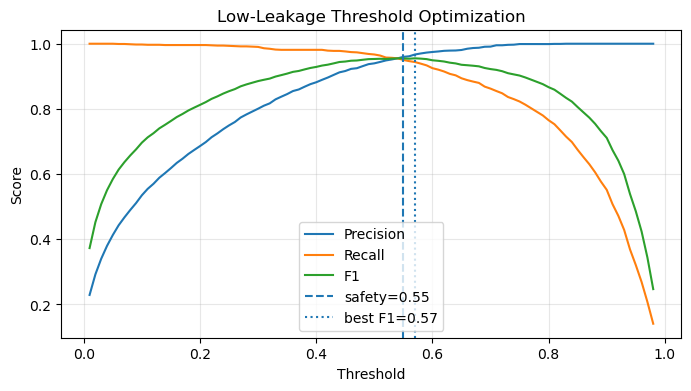

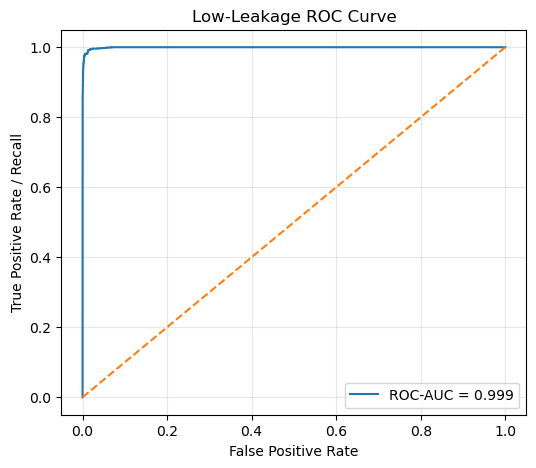

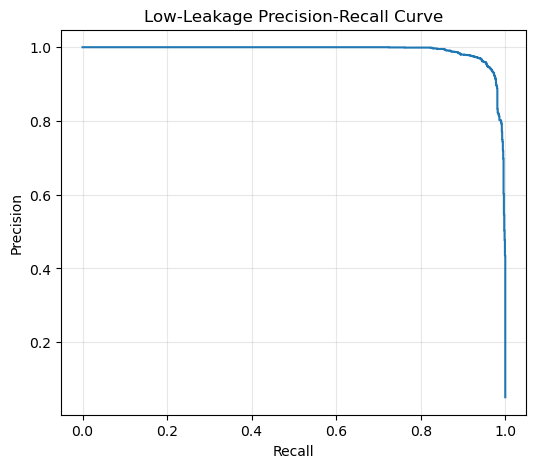


Top features:
                     feature  importance
11        flow_short_vs_long    0.220560
7                    rain_7d    0.118324
6                    rain_3d    0.102442
3                flow_3d_avg    0.099617
9              rain_per_area    0.078686
8                   rain_14d    0.071166
4                flow_7d_avg    0.050764
0                  flow_lag1    0.047433
5               flow_14d_avg    0.040366
12  river_drainage_area_sqmi    0.034091
1                  flow_lag2    0.033406
2                  flow_lag3    0.026840
10           rain_flow_ratio    0.024839
14            river_latitude    0.024679
13        river_elevation_ft    0.015765
15           river_longitude    0.011024


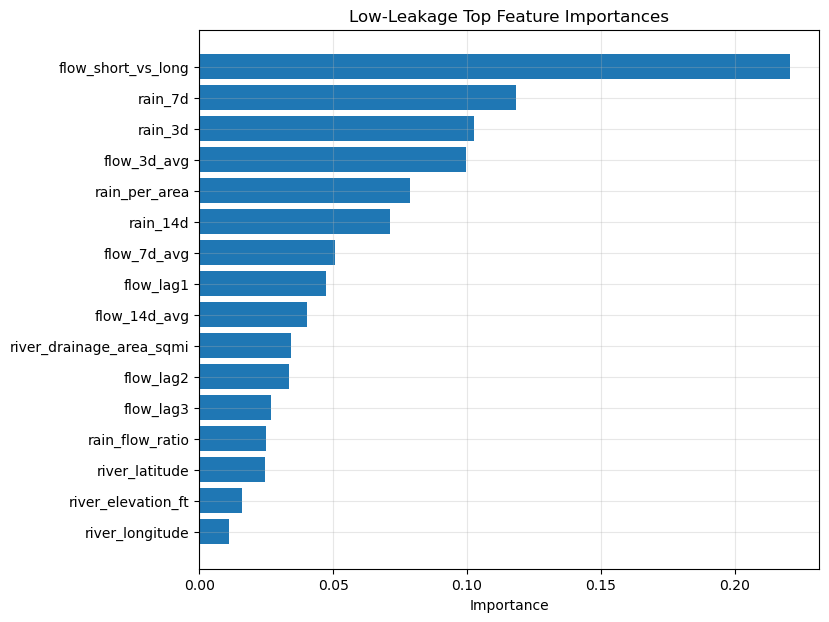


Saved:
- final_low_leakage_is_flood_classifier.pkl
- final_low_leakage_feature_medians.pkl
- final_low_leakage_thresholds.csv
- final_low_leakage_feature_importance.csv
- final_low_leakage_summary.csv

Summary:
   chosen_threshold  precision    recall        f1   roc_auc  n_rows  n_features  recall_target  best_cv_recall_search
0              0.55   0.959671  0.950285  0.954955  0.999364   48259          16           0.95               0.966993


In [ ]:
# =========================================================
# FINAL CLEAN CLASSIFIER - LOW LEAKAGE VERSION
# Uses ONLY rows where is_flood is not NaN
# Focus: high recall for flood safety
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc
)

# =========================================================
# 1) KEEP full_df UNCHANGED + BUILD CLEAN LABELED DATA
# =========================================================

full_df = full_df.loc[:, ~full_df.columns.duplicated()].copy()

if "is_flood" not in full_df.columns:
    raise ValueError("is_flood column is missing.")

cls_label_df = full_df[full_df["is_flood"].notna()].copy()
cls_label_df["is_flood"] = cls_label_df["is_flood"].astype(int)

print("Labeled rows:", cls_label_df.shape)
print("Label distribution:")
print(cls_label_df["is_flood"].value_counts())
print(cls_label_df["is_flood"].value_counts(normalize=True))

# =========================================================
# 2) SAFE FEATURE ENGINEERING
# no current flow, no target, no future columns
# =========================================================

# Rain unification if needed
rain_sources = [
    "rain",
    "usgs_00045_precipitation_total_inches",
    "weather_precipitation_sum",
]

existing_rain_sources = [c for c in rain_sources if c in cls_label_df.columns]

if len(existing_rain_sources) > 0:
    cls_label_df["rain_clean"] = cls_label_df[existing_rain_sources].bfill(axis=1).iloc[:, 0]
else:
    cls_label_df["rain_clean"] = np.nan

# Safe derived features from past/known variables only
if "rain_7d" in cls_label_df.columns:
    cls_label_df["rain_spike_7d"] = cls_label_df["rain_clean"] / (cls_label_df["rain_7d"] + 1e-6)

if "rain_14d" in cls_label_df.columns:
    cls_label_df["rain_spike_14d"] = cls_label_df["rain_clean"] / (cls_label_df["rain_14d"] + 1e-6)

if "flow_lag1" in cls_label_df.columns and "flow_lag7" in cls_label_df.columns:
    cls_label_df["lag_flow_rise_1_7"] = cls_label_df["flow_lag1"] - cls_label_df["flow_lag7"]

if "flow_3d_avg" in cls_label_df.columns and "flow_14d_avg" in cls_label_df.columns:
    cls_label_df["flow_short_vs_long"] = cls_label_df["flow_3d_avg"] / (cls_label_df["flow_14d_avg"] + 1e-6)

# =========================================================
# 3) LOW-LEAKAGE FEATURE LIST
# IMPORTANT: no "flow" current value
# =========================================================

candidate_features = [
    # past flow only
    "flow_lag1",
    "flow_lag2",
    "flow_lag3",
    "flow_lag4",
    "flow_lag5",
    "flow_lag6",
    "flow_lag7",
    "flow_3d_avg",
    "flow_7d_avg",
    "flow_14d_avg",

    # rainfall
    "rain_clean",
    "rain_lag1",
    "rain_lag2",
    "rain_lag3",
    "rain_lag4",
    "rain_lag5",
    "rain_lag6",
    "rain_lag7",
    "rain_3d",
    "rain_7d",
    "rain_14d",
    "rain_flow_interaction",
    "rain_per_area",
    "rain_flow_ratio",
    "rain_spike_7d",
    "rain_spike_14d",

    # trend/dynamics that should be past-based
    "flow_diff",
    "flow_acc",
    "lag_flow_rise_1_7",
    "flow_short_vs_long",

    # seasonality
    "dry_streak",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos",

    # static river features
    "river_drainage_area_sqmi",
    "river_mainstem_length_km",
    "river_elevation_ft",
    "river_contrib_drainage_area_sqmi",
    "river_gage_datum_ft",
    "river_latitude",
    "river_longitude",
]

# Forbidden leakage names
forbidden_keywords = [
    "target",
    "future",
    "pred",
    "prediction",
    "is_flood",
    "flood_level",
    "class",
    "capacity_q95",  # avoid using threshold/label proxy
    "true_flow",
]

cls_features = []

for c in candidate_features:
    if c not in cls_label_df.columns:
        continue

    if not pd.api.types.is_numeric_dtype(cls_label_df[c]):
        continue

    if any(k in c.lower() for k in forbidden_keywords):
        continue

    cls_features.append(c)

print("\nFinal low-leakage features:")
print(cls_features)
print("Number of features:", len(cls_features))

if len(cls_features) == 0:
    raise ValueError("No classification features found.")

# =========================================================
# 4) BUILD X/y
# =========================================================

X = cls_label_df[cls_features].copy()
y = cls_label_df["is_flood"].astype(int)

# Replace inf
X = X.replace([np.inf, -np.inf], np.nan)

# Fill NaN using global medians within labeled data
medians = X.median(numeric_only=True)
X = X.fillna(medians)

# Drop columns still all NaN or constant
bad_cols = []
for c in X.columns:
    if X[c].isna().all() or X[c].nunique(dropna=True) <= 1:
        bad_cols.append(c)

if bad_cols:
    print("\nDropping bad/constant columns:")
    print(bad_cols)
    X = X.drop(columns=bad_cols)
    cls_features = [c for c in cls_features if c not in bad_cols]

print("\nX:", X.shape)
print("y distribution:")
print(y.value_counts(normalize=True))

# =========================================================
# 5) CROSS-VALIDATED HYPERPARAMETER TUNING
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

base_rf = RandomForestClassifier(
    class_weight={0: 1, 1: 5},   # prioritize flood recall
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_split": [10, 20, 40],
    "min_samples_leaf": [3, 5, 8, 12],
    "max_features": ["sqrt", "log2", 0.5],
}

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_grid,
    n_iter=30,
    scoring="recall",   # safety-first
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X, y)

print("\nBest params:")
print(search.best_params_)
print("Best CV recall:", search.best_score_)

best_rf = search.best_estimator_

# =========================================================
# 6) CROSS-VALIDATED PROBABILITIES
# =========================================================

cv_probs = cross_val_predict(
    best_rf,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

cv_roc_auc = roc_auc_score(y, cv_probs)

print("\nCV ROC-AUC:", cv_roc_auc)

# =========================================================
# 7) THRESHOLD OPTIMIZATION
# =========================================================

threshold_rows = []

for thr in np.arange(0.01, 0.99, 0.01):
    pred = (cv_probs >= thr).astype(int)

    threshold_rows.append({
        "threshold": thr,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)

# Safety-first options
RECALL_TARGET = 0.95

safe_options = threshold_df[threshold_df["recall"] >= RECALL_TARGET].copy()

if len(safe_options) > 0:
    chosen_row = safe_options.sort_values(["precision", "f1"], ascending=False).iloc[0]
else:
    chosen_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

chosen_thr = float(chosen_row["threshold"])

# also show best F1
best_f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

print("\nBest F1 threshold:")
print(best_f1_row)

print("\nChosen SAFETY threshold:")
print(chosen_row)

cv_pred = (cv_probs >= chosen_thr).astype(int)

# =========================================================
# 8) FINAL CV METRICS
# =========================================================

precision = precision_score(y, cv_pred, zero_division=0)
recall = recall_score(y, cv_pred, zero_division=0)
f1 = f1_score(y, cv_pred, zero_division=0)

print("\n=== FINAL LOW-LEAKAGE CV CLASSIFICATION ===")
print("Threshold:", chosen_thr)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)
print("ROC-AUC  :", cv_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y, cv_pred))

print("\nClassification Report:")
print(classification_report(y, cv_pred, zero_division=0))

# =========================================================
# 9) PLOTS
# =========================================================

plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(chosen_thr, linestyle="--", label=f"safety={chosen_thr:.2f}")
plt.axvline(float(best_f1_row["threshold"]), linestyle=":", label=f"best F1={float(best_f1_row['threshold']):.2f}")
plt.title("Low-Leakage Threshold Optimization")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

fpr, tpr, _ = roc_curve(y, cv_probs)
roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_curve:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Low-Leakage ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

pr_precision, pr_recall, _ = precision_recall_curve(y, cv_probs)

plt.figure(figsize=(6, 5))
plt.plot(pr_recall, pr_precision)
plt.title("Low-Leakage Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 10) FEATURE IMPORTANCE + SAVE FINAL MODEL
# =========================================================

best_rf.fit(X, y)

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop features:")
print(feature_importance_df.head(25))

plt.figure(figsize=(8, 7))
plt.barh(
    feature_importance_df.head(20)["feature"][::-1],
    feature_importance_df.head(20)["importance"][::-1]
)
plt.title("Low-Leakage Top Feature Importances")
plt.xlabel("Importance")
plt.grid(True, alpha=0.3)
plt.show()

# Save
joblib.dump(best_rf, "final_low_leakage_is_flood_classifier.pkl")
joblib.dump(medians, "final_low_leakage_feature_medians.pkl")

threshold_df.to_csv("final_low_leakage_thresholds.csv", index=False)
feature_importance_df.to_csv("final_low_leakage_feature_importance.csv", index=False)

summary_df = pd.DataFrame([{
    "chosen_threshold": chosen_thr,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": cv_roc_auc,
    "n_rows": len(y),
    "n_features": X.shape[1],
    "recall_target": RECALL_TARGET,
    "best_cv_recall_search": search.best_score_,
}])

summary_df.to_csv("final_low_leakage_summary.csv", index=False)

print("\nSaved:")
print("- final_low_leakage_is_flood_classifier.pkl")
print("- final_low_leakage_feature_medians.pkl")
print("- final_low_leakage_thresholds.csv")
print("- final_low_leakage_feature_importance.csv")
print("- final_low_leakage_summary.csv")

print("\nSummary:")
print(summary_df)

In [90]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, cv_pred)
print(cm)

[[45707    98]
 [  122  2332]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

rows = []

for thr in np.arange(0.01, 0.99, 0.01):
    pred = (cv_probs >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()

    rows.append({
        "threshold": thr,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "FN": fn,
        "FP": fp,
        "TP": tp,
        "TN": tn,
    })

thr_df = pd.DataFrame(rows)

# ===========================
# OPTION A: 
# ===========================
best_fn = thr_df.sort_values(["FN", "precision"]).iloc[0]

print("=== MIN FN OPTION ===")
print(best_fn)

# ===========================
# OPTION B: Recall ≥ 0.99
# ===========================
safe = thr_df[thr_df["recall"] >= 0.99]

if len(safe) > 0:
    best_safe = safe.sort_values(["precision"], ascending=False).iloc[0]
    print("\n=== SAFETY (recall ≥ 0.99) ===")
    print(best_safe)
else:
    print("\nNo threshold reaches recall ≥ 0.99")

# اختار
chosen_thr = float(best_fn["threshold"])
print("\nChosen threshold:", chosen_thr)

=== MIN FN OPTION ===
threshold        0.010000
precision        0.229282
recall           1.000000
f1               0.373033
FN               0.000000
FP            8249.000000
TP            2454.000000
TN           37556.000000
Name: 0, dtype: float64

=== SAFETY (recall ≥ 0.99) ===
threshold        0.300000
precision        0.800659
recall           0.990220
f1               0.885407
FN              24.000000
FP             605.000000
TP            2430.000000
TN           45200.000000
Name: 29, dtype: float64

Chosen threshold: 0.01


In [92]:
import joblib

# model
joblib.dump(best_rf, "flood_classifier.pkl")

# threshold
joblib.dump(0.30, "flood_threshold.pkl")

# medians
joblib.dump(medians, "feature_medians.pkl")

# features list 
joblib.dump(cls_features, "features_list.pkl")

print("Saved successfully")

Saved successfully


we want to drop colums that not have values

In [93]:
drop_cols = [
    "river_mainstem_length_km",
    "river_contrib_drainage_area_sqmi",
    "river_gage_datum_ft"
]

full_df = full_df.drop(columns=[c for c in drop_cols if c in full_df.columns])

## Normalize discharge by basin size

We normalize discharge by drainage area to compare rivers of different sizes.

df shape: (67888, 71)
features: 59
date range: 2014-01-15 00:00:00 to 2024-12-21 00:00:00

Split:
Train: (47528, 71) 2014-01-15 00:00:00 → 2021-09-10 00:00:00
Valid: (6783, 71) 2021-09-11 00:00:00 → 2022-10-14 00:00:00
Test : (13577, 71) 2022-10-15 00:00:00 → 2024-12-21 00:00:00

Rivers:
Train: 17
Valid: 17
Test : 17

X_train_base: (47528, 59)
X_valid_base: (6783, 59)
X_test_base : (13577, 59)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12949
[LightGBM] [Info] Number of data points in the train set: 47528, number of used features: 59
[LightGBM] [Info] Start training from score 5.667270
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010553 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12949
[LightGBM] [Info] Number of data points in the train set: 47528

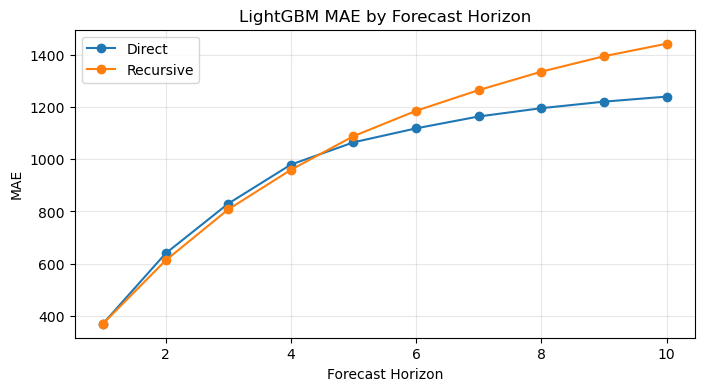

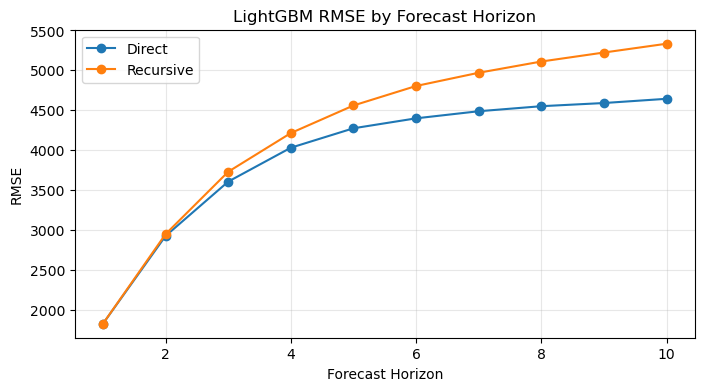

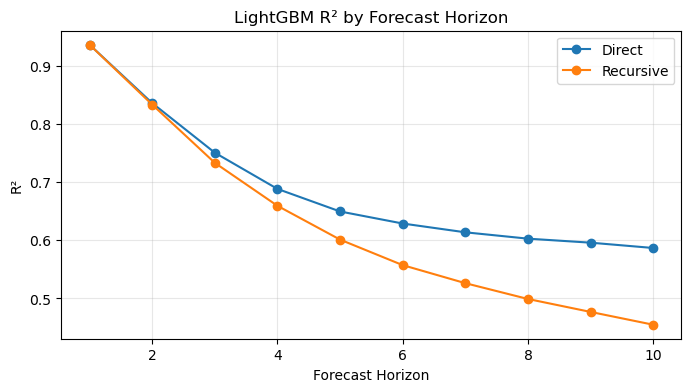

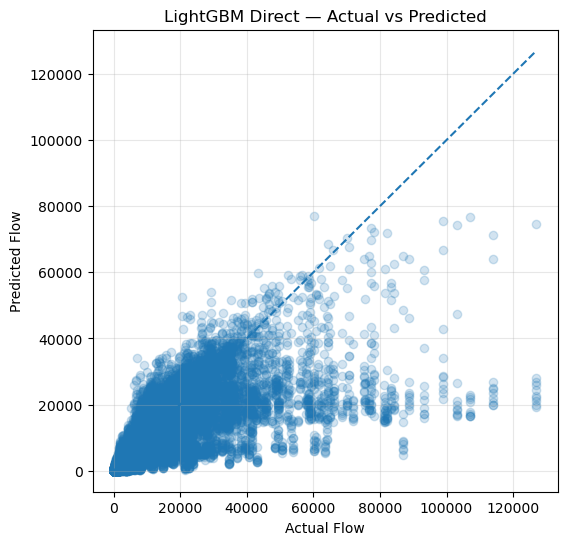

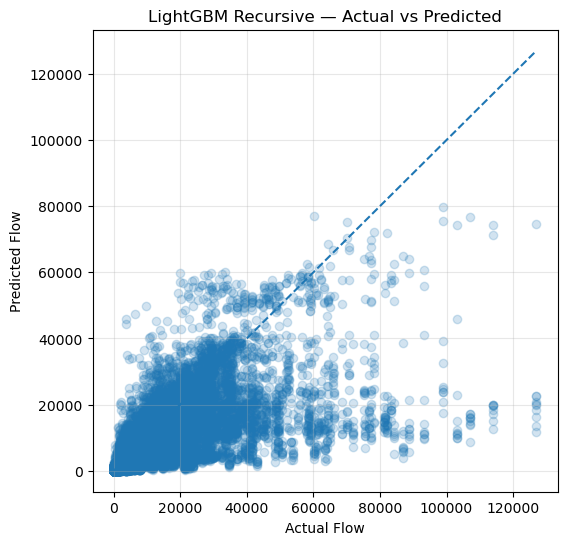

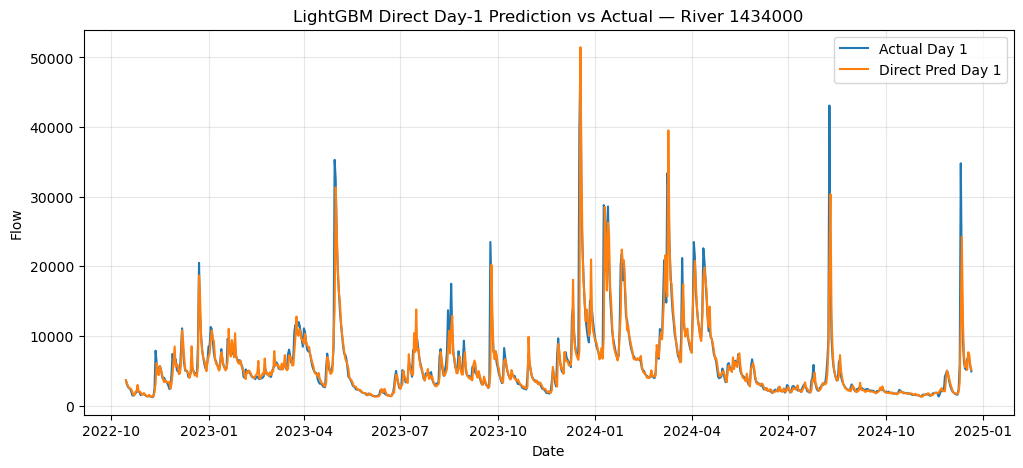

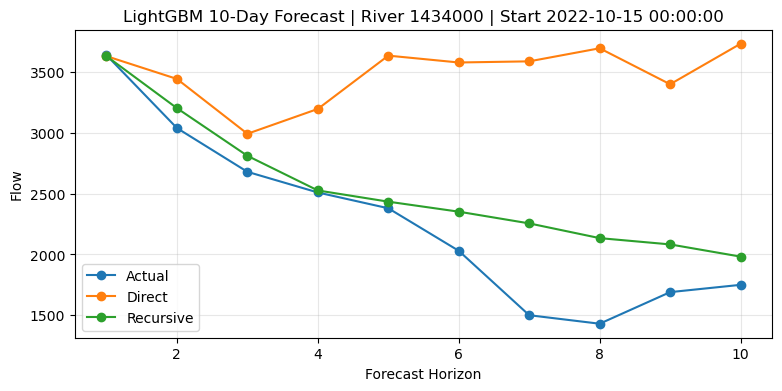


Top 25 LightGBM Day-1 feature importances:
                               feature  importance
0                                 flow        1750
1                                 rain        1077
43                             doy_sin        1030
57  weather_et0_fao_evapotranspiration         978
54   weather_relative_humidity_2m_mean         946
51          weather_temperature_2m_max         758
44                             doy_cos         714
46            river_drainage_area_sqmi         622
58       weather_surface_pressure_mean         615
56          weather_wind_gusts_10m_max         496
52          weather_temperature_2m_min         461
53         weather_precipitation_hours         456
35                            rain_14d         455
50         weather_temperature_2m_mean         454
16                           rain_lag1         453
55          weather_wind_speed_10m_max         445
36                           flow_diff         428
22                           rain_lag7

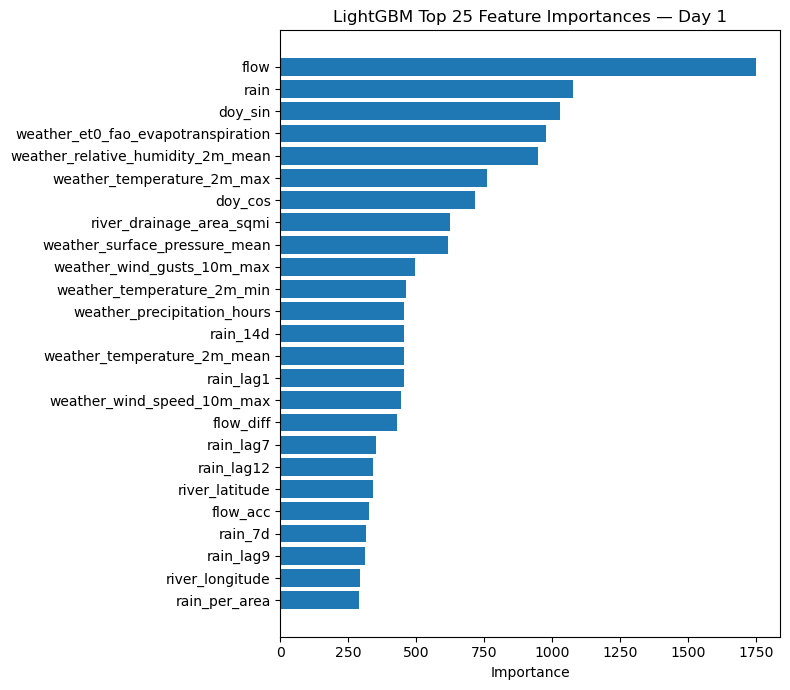


Saved:
- lightgbm_direct_recursive_regression_bundle.pkl
- lightgbm_direct_metrics_by_horizon.csv
- lightgbm_recursive_metrics_by_horizon.csv
- lightgbm_direct_vs_recursive_comparison.csv
- lightgbm_direct_overall_metrics.csv
- lightgbm_recursive_overall_metrics.csv
- lightgbm_day1_feature_importance.csv
- lightgbm_recursive_predictions.npy
- lightgbm_recursive_truths.npy


In [137]:
# =========================================================
# LIGHTGBM REGRESSION — DIRECT + RECURSIVE
# Clean version for multi-horizon streamflow forecasting
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 0) CONFIG
# =========================================================

HORIZON = 10
MAX_LAG = 14

target_cols = [f"flow_target_day{h}" for h in range(1, HORIZON + 1)]

FEATURES_TO_USE = regression_features.copy()

# Safety leakage check
forbidden_keywords = [
    "target",
    "class",
    "flood",
    "is_flood",
    "pred",
    "true_",
    "capacity",
]

bad_features = [
    c for c in FEATURES_TO_USE
    if any(k in c.lower() for k in forbidden_keywords)
]

if bad_features:
    raise ValueError(f"Leakage features found in FEATURES_TO_USE: {bad_features}")

required_cols = ["river_id", "date"] + FEATURES_TO_USE + target_cols
missing_cols = [c for c in required_cols if c not in model_df.columns]

if missing_cols:
    raise ValueError(f"Missing columns in model_df: {missing_cols}")

df = model_df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values(["date", "river_id"]).reset_index(drop=True)

print("df shape:", df.shape)
print("features:", len(FEATURES_TO_USE))
print("date range:", df["date"].min(), "to", df["date"].max())

# =========================================================
# 1) TIME-BASED TRAIN / VALID / TEST SPLIT
# =========================================================

train_end_date = df["date"].quantile(0.70)
valid_end_date = df["date"].quantile(0.80)

train_df = df[df["date"] <= train_end_date].copy()

valid_df = df[
    (df["date"] > train_end_date) &
    (df["date"] <= valid_end_date)
].copy()

test_df = df[df["date"] > valid_end_date].copy()

print("\nSplit:")
print("Train:", train_df.shape, train_df["date"].min(), "→", train_df["date"].max())
print("Valid:", valid_df.shape, valid_df["date"].min(), "→", valid_df["date"].max())
print("Test :", test_df.shape, test_df["date"].min(), "→", test_df["date"].max())

print("\nRivers:")
print("Train:", train_df["river_id"].nunique())
print("Valid:", valid_df["river_id"].nunique())
print("Test :", test_df["river_id"].nunique())

# =========================================================
# 2) PREPARE BASE MATRICES
# =========================================================

X_train_base = train_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()
X_valid_base = valid_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()
X_test_base  = test_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()

print("\nX_train_base:", X_train_base.shape)
print("X_valid_base:", X_valid_base.shape)
print("X_test_base :", X_test_base.shape)

# =========================================================
# 3) MODEL FACTORY
# =========================================================

def make_lgbm_model(seed=42):
    return LGBMRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1
    )

# =========================================================
# 4) DIRECT MULTI-HORIZON LIGHTGBM
# model_1 predicts day1, model_2 predicts day2, ...
# =========================================================

direct_models = {}
direct_preds_by_h = {}
direct_truths_by_h = {}
direct_metrics_rows = []

for h in range(1, HORIZON + 1):
    target_col = f"flow_target_day{h}"

    y_train = train_df[target_col].copy()
    y_test = test_df[target_col].copy()

    train_mask = y_train.notna()
    test_mask = y_test.notna()

    X_tr = X_train_base.loc[train_mask].copy()
    y_tr = y_train.loc[train_mask].copy()

    X_te = X_test_base.loc[test_mask].copy()
    y_te = y_test.loc[test_mask].copy()

    # log transform because flow is highly skewed
    y_tr_log = np.log1p(y_tr)

    model = make_lgbm_model(seed=42 + h)
    model.fit(X_tr, y_tr_log)

    pred_log = model.predict(X_te)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    direct_models[h] = model
    direct_preds_by_h[h] = pd.Series(pred, index=X_te.index)
    direct_truths_by_h[h] = y_te

    direct_metrics_rows.append({
        "horizon_day": h,
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "R2": r2_score(y_te, pred),
        "n_test": len(y_te)
    })

direct_metrics_df = pd.DataFrame(direct_metrics_rows)

direct_all_true = np.concatenate([direct_truths_by_h[h].values for h in range(1, HORIZON + 1)])
direct_all_pred = np.concatenate([direct_preds_by_h[h].values for h in range(1, HORIZON + 1)])

direct_overall = {
    "MAE": mean_absolute_error(direct_all_true, direct_all_pred),
    "RMSE": np.sqrt(mean_squared_error(direct_all_true, direct_all_pred)),
    "R2": r2_score(direct_all_true, direct_all_pred),
}

print("\n=== LIGHTGBM DIRECT METRICS BY HORIZON ===")
print(direct_metrics_df)

print("\n=== LIGHTGBM DIRECT OVERALL ===")
print(direct_overall)

# =========================================================
# 5) RECURSIVE LIGHTGBM
# Train/use day-1 model, then feed prediction back as latest flow
# =========================================================

recursive_model = direct_models[1]

def build_recursive_lgbm_row(base_row, flow_hist, rain_hist, current_date):
    """
    Build one feature row for recursive forecasting.

    flow_hist[0] = latest known/predicted flow
    flow_hist[1] = previous day flow
    ...
    rain_hist[0] = latest known/assumed rain
    """

    feat = {}

    # fallback from original row
    for col in FEATURES_TO_USE:
        feat[col] = base_row[col] if col in base_row.index else np.nan

    # update current flow/rain
    if "flow" in feat:
        feat["flow"] = flow_hist[0]

    if "rain" in feat:
        feat["rain"] = rain_hist[0]

    # update lag features
    for lag in range(1, MAX_LAG + 1):
        flow_col = f"flow_lag{lag}"
        rain_col = f"rain_lag{lag}"

        if flow_col in feat:
            feat[flow_col] = flow_hist[lag] if lag < len(flow_hist) else np.nan

        if rain_col in feat:
            feat[rain_col] = rain_hist[lag] if lag < len(rain_hist) else np.nan

    # rolling flow summaries: past only
    if "flow_3d_avg" in feat:
        feat["flow_3d_avg"] = np.mean(flow_hist[1:4]) if len(flow_hist) >= 4 else np.nan

    if "flow_7d_avg" in feat:
        feat["flow_7d_avg"] = np.mean(flow_hist[1:8]) if len(flow_hist) >= 8 else np.nan

    if "flow_14d_avg" in feat:
        feat["flow_14d_avg"] = np.mean(flow_hist[1:15]) if len(flow_hist) >= 15 else np.nan

    # rolling rain summaries: past only
    if "rain_3d" in feat:
        feat["rain_3d"] = np.sum(rain_hist[1:4]) if len(rain_hist) >= 4 else np.nan

    if "rain_7d" in feat:
        feat["rain_7d"] = np.sum(rain_hist[1:8]) if len(rain_hist) >= 8 else np.nan

    if "rain_14d" in feat:
        feat["rain_14d"] = np.sum(rain_hist[1:15]) if len(rain_hist) >= 15 else np.nan

    # dynamics
    if "flow_diff" in feat:
        feat["flow_diff"] = flow_hist[1] - flow_hist[2] if len(flow_hist) >= 3 else np.nan

    if "flow_acc" in feat:
        if len(flow_hist) >= 4:
            diff1 = flow_hist[1] - flow_hist[2]
            diff2 = flow_hist[2] - flow_hist[3]
            feat["flow_acc"] = diff1 - diff2
        else:
            feat["flow_acc"] = np.nan

    # dry streak
    if "dry_streak" in feat:
        count = 0
        for r in rain_hist:
            if r == 0:
                count += 1
            else:
                break
        feat["dry_streak"] = count

    # seasonality
    if pd.notna(current_date):
        month = current_date.month
        doy = current_date.dayofyear

        if "month_sin" in feat:
            feat["month_sin"] = np.sin(2 * np.pi * month / 12)
        if "month_cos" in feat:
            feat["month_cos"] = np.cos(2 * np.pi * month / 12)
        if "doy_sin" in feat:
            feat["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
        if "doy_cos" in feat:
            feat["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # interactions
    if "rain_flow_interaction" in feat:
        feat["rain_flow_interaction"] = feat.get("rain_3d", np.nan) * feat.get("flow_lag1", np.nan)

    if "rain_flow_ratio" in feat:
        feat["rain_flow_ratio"] = feat.get("rain_3d", np.nan) / (feat.get("flow_lag1", np.nan) + 1)

    if "rain_per_area" in feat:
        area = feat.get("river_drainage_area_sqmi", np.nan)
        rain_3d_val = feat.get("rain_3d", np.nan)
        feat["rain_per_area"] = rain_3d_val / (area + 1e-6)

    return pd.DataFrame([feat])[FEATURES_TO_USE]


def recursive_lgbm_forecast(row, model, horizon=10, future_rain_value=0.0):
    """
    Recursive forecast:
    day1 predicted from current features.
    Then predicted day1 becomes the new flow input for day2.
    Future rainfall is unknown, so by default assumed 0.0.
    """

    # current + past flow history
    flow_hist = [float(row["flow"])]

    for lag in range(1, MAX_LAG + 1):
        col = f"flow_lag{lag}"
        if col in row.index and pd.notna(row[col]):
            flow_hist.append(float(row[col]))

    # current + past rain history
    if "rain" in row.index and pd.notna(row["rain"]):
        rain_hist = [float(row["rain"])]
    else:
        rain_hist = [0.0]

    for lag in range(1, MAX_LAG + 1):
        col = f"rain_lag{lag}"
        if col in row.index and pd.notna(row[col]):
            rain_hist.append(float(row[col]))

    preds = []
    base_date = row["date"] if "date" in row.index else pd.NaT

    for step in range(1, horizon + 1):
        current_date = base_date + pd.Timedelta(days=step - 1) if pd.notna(base_date) else pd.NaT

        X_one = build_recursive_lgbm_row(
            base_row=row,
            flow_hist=flow_hist,
            rain_hist=rain_hist,
            current_date=current_date
        )

        pred_log = model.predict(X_one)[0]
        pred = np.expm1(pred_log)
        pred = max(float(pred), 0.0)

        preds.append(pred)

        # recursive update
        flow_hist = [pred] + flow_hist

        # no future rainfall unless provided externally
        rain_hist = [future_rain_value] + rain_hist

    return preds

# =========================================================
# 6) RUN RECURSIVE FORECAST ON TEST SET
# =========================================================

recursive_test_df = test_df.dropna(subset=["flow", "rain"] + target_cols).copy()
recursive_test_df = recursive_test_df.sort_values(["date", "river_id"]).reset_index(drop=True)

rec_preds = []
rec_truths = []
rec_meta = []

for _, row in recursive_test_df.iterrows():
    preds = recursive_lgbm_forecast(
        row=row,
        model=recursive_model,
        horizon=HORIZON,
        future_rain_value=0.0
    )

    truths = [row[f"flow_target_day{h}"] for h in range(1, HORIZON + 1)]

    rec_preds.append(preds)
    rec_truths.append(truths)
    rec_meta.append((row["river_id"], row["date"]))

rec_preds = np.array(rec_preds, dtype=float)
rec_truths = np.array(rec_truths, dtype=float)

print("\nRecursive preds:", rec_preds.shape)
print("Recursive truths:", rec_truths.shape)

recursive_metrics_rows = []

for h in range(HORIZON):
    y_true = rec_truths[:, h]
    y_pred = rec_preds[:, h]

    recursive_metrics_rows.append({
        "horizon_day": h + 1,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    })

recursive_metrics_df = pd.DataFrame(recursive_metrics_rows)

recursive_overall = {
    "MAE": mean_absolute_error(rec_truths.reshape(-1), rec_preds.reshape(-1)),
    "RMSE": np.sqrt(mean_squared_error(rec_truths.reshape(-1), rec_preds.reshape(-1))),
    "R2": r2_score(rec_truths.reshape(-1), rec_preds.reshape(-1)),
}

print("\n=== LIGHTGBM RECURSIVE METRICS BY HORIZON ===")
print(recursive_metrics_df)

print("\n=== LIGHTGBM RECURSIVE OVERALL ===")
print(recursive_overall)

# =========================================================
# 7) DIRECT VS RECURSIVE COMPARISON
# =========================================================

comparison_df = direct_metrics_df.merge(
    recursive_metrics_df,
    on="horizon_day",
    suffixes=("_direct", "_recursive")
)

print("\n=== DIRECT VS RECURSIVE COMPARISON ===")
print(comparison_df)

# =========================================================
# 8) PLOTS — METRICS
# =========================================================

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["MAE_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["MAE_recursive"], marker="o", label="Recursive")
plt.title("LightGBM MAE by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["RMSE_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["RMSE_recursive"], marker="o", label="Recursive")
plt.title("LightGBM RMSE by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["R2_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["R2_recursive"], marker="o", label="Recursive")
plt.title("LightGBM R² by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("R²")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 9) ACTUAL VS PREDICTED SCATTERS
# =========================================================

plt.figure(figsize=(6, 6))
plt.scatter(direct_all_true, direct_all_pred, alpha=0.20)
min_val = min(direct_all_true.min(), direct_all_pred.min())
max_val = max(direct_all_true.max(), direct_all_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("LightGBM Direct — Actual vs Predicted")
plt.xlabel("Actual Flow")
plt.ylabel("Predicted Flow")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(rec_truths.reshape(-1), rec_preds.reshape(-1), alpha=0.20)
min_val = min(rec_truths.min(), rec_preds.min())
max_val = max(rec_truths.max(), rec_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("LightGBM Recursive — Actual vs Predicted")
plt.xlabel("Actual Flow")
plt.ylabel("Predicted Flow")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 10) TIME-SERIES PLOT FOR ONE RIVER — DAY 1 DIRECT
# =========================================================

sample_river = test_df["river_id"].iloc[0]
tmp = test_df[test_df["river_id"] == sample_river].copy()
tmp = tmp.sort_values("date").copy()

tmp["pred_direct_day1"] = direct_preds_by_h[1].reindex(tmp.index)

plt.figure(figsize=(12, 5))
plt.plot(tmp["date"], tmp["flow_target_day1"], label="Actual Day 1")
plt.plot(tmp["date"], tmp["pred_direct_day1"], label="Direct Pred Day 1")
plt.title(f"LightGBM Direct Day-1 Prediction vs Actual — River {sample_river}")
plt.xlabel("Date")
plt.ylabel("Flow")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 11) SAMPLE 10-DAY FORECAST: ACTUAL VS DIRECT VS RECURSIVE
# =========================================================

sample_idx = 0
sample_river, sample_date = rec_meta[sample_idx]

sample_actual = rec_truths[sample_idx]
sample_recursive = rec_preds[sample_idx]

sample_row = recursive_test_df.iloc[[sample_idx]][FEATURES_TO_USE].copy()

sample_direct = []
for h in range(1, HORIZON + 1):
    pred_log = direct_models[h].predict(sample_row)[0]
    pred = np.expm1(pred_log)
    pred = max(float(pred), 0.0)
    sample_direct.append(pred)

plt.figure(figsize=(9, 4))
plt.plot(range(1, HORIZON + 1), sample_actual, marker="o", label="Actual")
plt.plot(range(1, HORIZON + 1), sample_direct, marker="o", label="Direct")
plt.plot(range(1, HORIZON + 1), sample_recursive, marker="o", label="Recursive")
plt.title(f"LightGBM 10-Day Forecast | River {sample_river} | Start {sample_date}")
plt.xlabel("Forecast Horizon")
plt.ylabel("Flow")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 12) FEATURE IMPORTANCE — DAY 1 DIRECT MODEL
# =========================================================

feat_imp = pd.DataFrame({
    "feature": FEATURES_TO_USE,
    "importance": direct_models[1].feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 25 LightGBM Day-1 feature importances:")
print(feat_imp.head(25))

plt.figure(figsize=(8, 7))
top25 = feat_imp.head(25).sort_values("importance")
plt.barh(top25["feature"], top25["importance"])
plt.title("LightGBM Top 25 Feature Importances — Day 1")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 13) SAVE RESULTS
# =========================================================

bundle = {
    "direct_models": direct_models,
    "recursive_model": recursive_model,
    "features": FEATURES_TO_USE,
    "target_cols": target_cols,
    "horizon": HORIZON,
    "max_lag": MAX_LAG,
    "model_type": "LightGBM log1p direct + recursive",
    "future_rain_assumption_recursive": "future_rain_value = 0.0"
}

joblib.dump(bundle, "lightgbm_direct_recursive_regression_bundle.pkl")

direct_metrics_df.to_csv("lightgbm_direct_metrics_by_horizon.csv", index=False)
recursive_metrics_df.to_csv("lightgbm_recursive_metrics_by_horizon.csv", index=False)
comparison_df.to_csv("lightgbm_direct_vs_recursive_comparison.csv", index=False)

pd.DataFrame([direct_overall]).to_csv("lightgbm_direct_overall_metrics.csv", index=False)
pd.DataFrame([recursive_overall]).to_csv("lightgbm_recursive_overall_metrics.csv", index=False)

feat_imp.to_csv("lightgbm_day1_feature_importance.csv", index=False)

# Save predictions as compact arrays
np.save("lightgbm_recursive_predictions.npy", rec_preds)
np.save("lightgbm_recursive_truths.npy", rec_truths)

print("\nSaved:")
print("- lightgbm_direct_recursive_regression_bundle.pkl")
print("- lightgbm_direct_metrics_by_horizon.csv")
print("- lightgbm_recursive_metrics_by_horizon.csv")
print("- lightgbm_direct_vs_recursive_comparison.csv")
print("- lightgbm_direct_overall_metrics.csv")
print("- lightgbm_recursive_overall_metrics.csv")
print("- lightgbm_day1_feature_importance.csv")
print("- lightgbm_recursive_predictions.npy")
print("- lightgbm_recursive_truths.npy")

df: (67888, 71)
features: 59
date range: 2014-01-15 00:00:00 → 2024-12-21 00:00:00
rivers: 17

Split:
Train: (47528, 71) 2014-01-15 00:00:00 → 2021-09-10 00:00:00
Valid: (6783, 71) 2021-09-11 00:00:00 → 2022-10-14 00:00:00
Test : (13577, 71) 2022-10-15 00:00:00 → 2024-12-21 00:00:00

Sequences:
X_tr_seq: (23662, 14, 59)
X_va_seq: (1326, 14, 59)
X_te_seq: (2684, 14, 59)
y_tr_multi: (23662, 10)
y_te_multi: (2684, 10)

START DIRECT 10-DAY LSTM TRAINING...
Epoch 1/60
183/185 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1491 - mae: 0.3280
Epoch 1: val_loss improved from None to 0.08876, saving model to best_lstm_direct_10day.keras

Epoch 1: finished saving model to best_lstm_direct_10day.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.1124 - mae: 0.2526 - val_loss: 0.0888 - val_mae: 0.1801 - learning_rate: 5.0000e-04
Epoch 2/60
183/185 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0809 - mae: 0.1914
Epoch 2: val_loss improved from 0.08876 to 0.08413, saving model to best_lstm_direct_

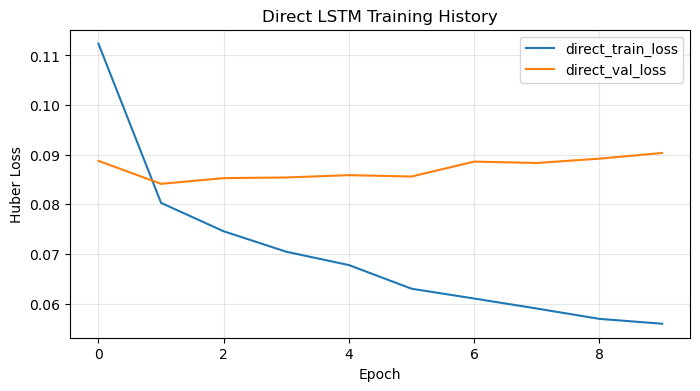

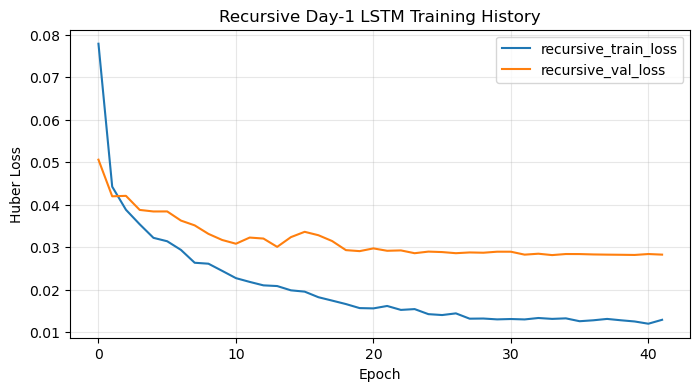

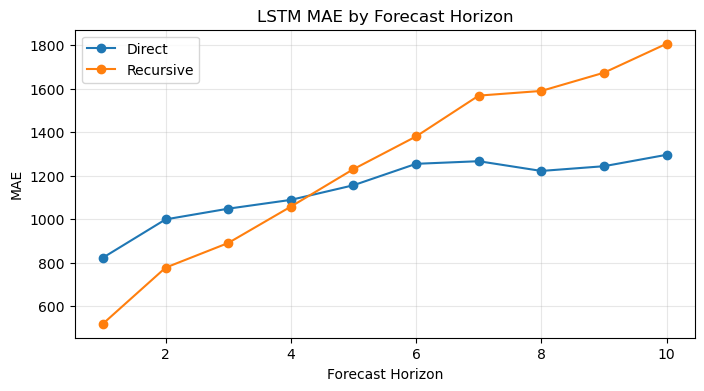

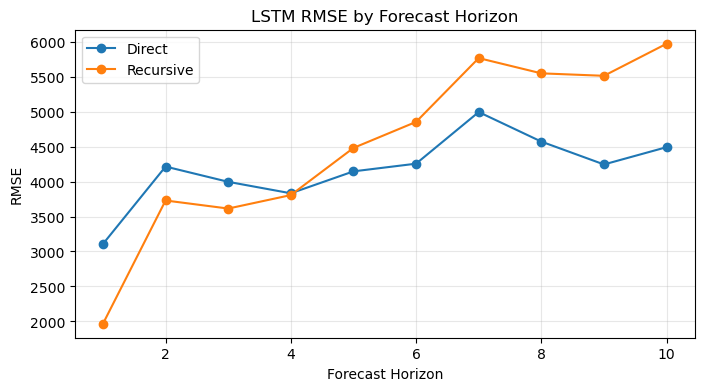

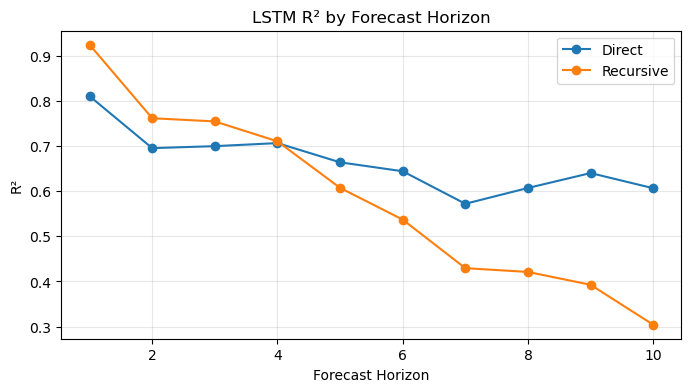

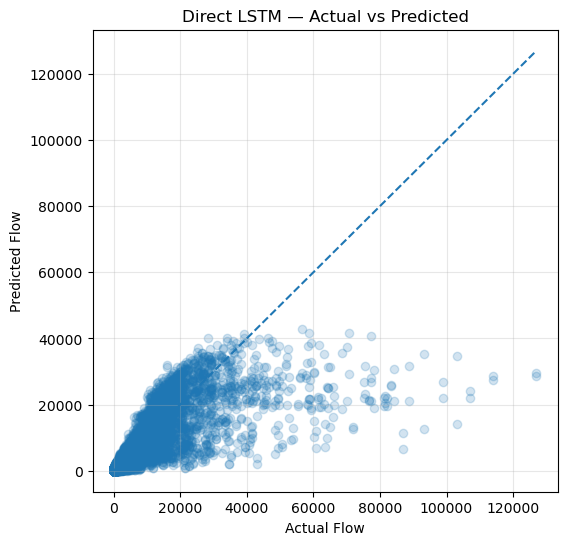

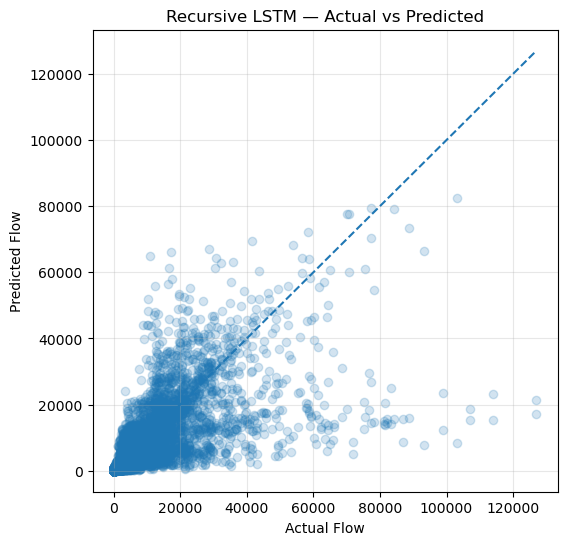

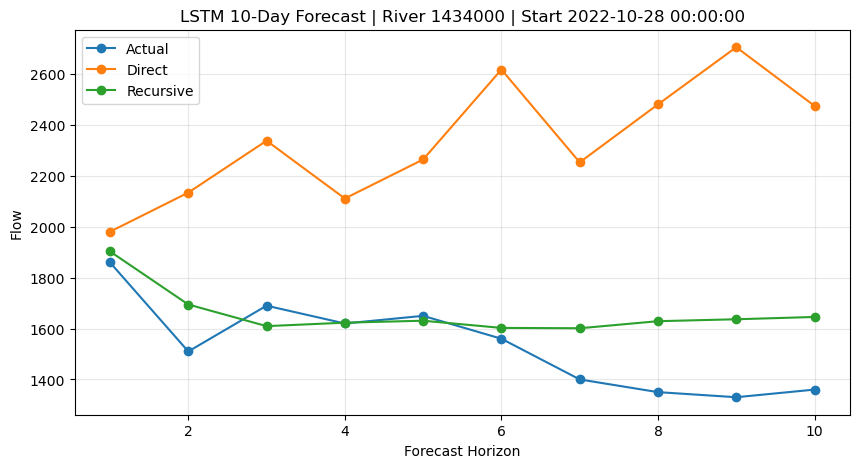


Saved:
- best_lstm_direct_10day.keras
- best_lstm_recursive_day1.keras
- lstm_feature_scaler.pkl
- lstm_direct_target_scaler.pkl
- lstm_recursive_target_scaler.pkl
- lstm_feature_medians.pkl
- lstm_direct_metrics_by_horizon.csv
- lstm_recursive_metrics_by_horizon.csv
- lstm_direct_vs_recursive_comparison.csv
- lstm_direct_overall_metrics.csv
- lstm_recursive_overall_metrics.csv
- lstm_direct_predictions.npy
- lstm_direct_truths.npy
- lstm_recursive_predictions.npy
- lstm_recursive_truths.npy
- lstm_direct_recursive_bundle.pkl


In [140]:
# =========================================================
# LSTM REGRESSION — DIRECT + RECURSIVE 10-DAY FORECASTING
# Optimized with STRIDE to reduce runtime
# No classification here
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# =========================================================
# 0) SETTINGS
# =========================================================

SEQ_LEN = 14
HORIZON = 10
MAX_LAG = 14

GROUP_COL = "river_id"
DATE_COL = "date"

# Speed controls
TRAIN_STRIDE = 2          # يقلل training sequences
EVAL_STRIDE = 5           # يقلل validation/test/recursive anchors
MAX_TRAIN_ANCHORS = None  # خليه None للتدريب، أو حط رقم إذا بدك أسرع
MAX_EVAL_ANCHORS = 5000

target_cols = [f"flow_target_day{h}" for h in range(1, HORIZON + 1)]

DIRECT_MODEL_PATH = "best_lstm_direct_10day.keras"
RECURSIVE_MODEL_PATH = "best_lstm_recursive_day1.keras"

FEATURE_SCALER_PATH = "lstm_feature_scaler.pkl"
DIRECT_TARGET_SCALER_PATH = "lstm_direct_target_scaler.pkl"
RECURSIVE_TARGET_SCALER_PATH = "lstm_recursive_target_scaler.pkl"
FEATURE_MEDIANS_PATH = "lstm_feature_medians.pkl"

np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# 1) SAFETY CHECKS
# =========================================================

df = model_df.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.sort_values([GROUP_COL, DATE_COL]).reset_index(drop=True)

FEATURES_TO_USE = regression_features.copy()

forbidden_keywords = [
    "target",
    "class",
    "flood",
    "is_flood",
    "pred",
    "true_",
    "capacity",
]

bad_features = [
    c for c in FEATURES_TO_USE
    if any(k in c.lower() for k in forbidden_keywords)
]

if bad_features:
    raise ValueError(f"Leakage features found: {bad_features}")

required_cols = [GROUP_COL, DATE_COL] + FEATURES_TO_USE + target_cols

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.dropna(subset=[GROUP_COL, DATE_COL] + FEATURES_TO_USE + target_cols).copy()
df = df.sort_values([GROUP_COL, DATE_COL]).reset_index(drop=True)

print("df:", df.shape)
print("features:", len(FEATURES_TO_USE))
print("date range:", df[DATE_COL].min(), "→", df[DATE_COL].max())
print("rivers:", df[GROUP_COL].nunique())

# =========================================================
# 2) TIME SPLIT
# =========================================================

df_time = df.sort_values([DATE_COL, GROUP_COL]).reset_index(drop=True)

train_end_date = df_time[DATE_COL].quantile(0.70)
valid_end_date = df_time[DATE_COL].quantile(0.80)

train_df = df_time[df_time[DATE_COL] <= train_end_date].copy()

valid_df = df_time[
    (df_time[DATE_COL] > train_end_date) &
    (df_time[DATE_COL] <= valid_end_date)
].copy()

test_df = df_time[df_time[DATE_COL] > valid_end_date].copy()

# sort back per river for sequences
train_df = train_df.sort_values([GROUP_COL, DATE_COL]).copy()
valid_df = valid_df.sort_values([GROUP_COL, DATE_COL]).copy()
test_df  = test_df.sort_values([GROUP_COL, DATE_COL]).copy()

print("\nSplit:")
print("Train:", train_df.shape, train_df[DATE_COL].min(), "→", train_df[DATE_COL].max())
print("Valid:", valid_df.shape, valid_df[DATE_COL].min(), "→", valid_df[DATE_COL].max())
print("Test :", test_df.shape,  test_df[DATE_COL].min(),  "→", test_df[DATE_COL].max())

# =========================================================
# 3) SCALE FEATURES
# =========================================================

X_train_raw = train_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()
X_valid_raw = valid_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()
X_test_raw  = test_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()

feature_medians = X_train_raw.median(numeric_only=True)

X_train_raw = X_train_raw.fillna(feature_medians)
X_valid_raw = X_valid_raw.fillna(feature_medians)
X_test_raw  = X_test_raw.fillna(feature_medians)

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_raw)

X_train_scaled_df = pd.DataFrame(
    feature_scaler.transform(X_train_raw),
    columns=FEATURES_TO_USE,
    index=train_df.index
)

X_valid_scaled_df = pd.DataFrame(
    feature_scaler.transform(X_valid_raw),
    columns=FEATURES_TO_USE,
    index=valid_df.index
)

X_test_scaled_df = pd.DataFrame(
    feature_scaler.transform(X_test_raw),
    columns=FEATURES_TO_USE,
    index=test_df.index
)

# target scalers
direct_target_scaler = StandardScaler()
recursive_target_scaler = StandardScaler()

direct_target_scaler.fit(train_df[target_cols].values)
recursive_target_scaler.fit(train_df[["flow_target_day1"]].values)

# =========================================================
# 4) BUILD SEQUENCES WITH STRIDE
# Sequence ends at current day, target = next 1..10 days
# =========================================================

def build_lstm_sequences(
    df_part,
    X_scaled_df,
    seq_len,
    target_cols,
    stride=1,
    max_anchors=None
):
    X_seq = []
    y_multi = []
    y_day1 = []
    meta = []
    base_rows = []

    for river_id, g in df_part.groupby(GROUP_COL, sort=False):
        g = g.sort_values(DATE_COL).copy()
        idx = g.index

        Xg = X_scaled_df.loc[idx].values.astype(np.float32)
        yg_multi = g[target_cols].values.astype(np.float32)
        dates = g[DATE_COL].values

        n = len(g)

        if n < seq_len:
            continue

        anchor_indices = np.arange(seq_len - 1, n, stride)

        if max_anchors is not None and len(anchor_indices) > max_anchors:
            anchor_indices = np.linspace(
                anchor_indices[0],
                anchor_indices[-1],
                max_anchors,
                dtype=int
            )

        for i in anchor_indices:
            X_seq.append(Xg[i - seq_len + 1 : i + 1, :])
            y_multi.append(yg_multi[i, :])
            y_day1.append(yg_multi[i, 0])
            meta.append((river_id, pd.Timestamp(dates[i])))
            base_rows.append(g.iloc[i].copy())

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_multi, dtype=np.float32),
        np.array(y_day1, dtype=np.float32),
        meta,
        base_rows
    )


X_tr_seq, y_tr_multi, y_tr_day1, meta_tr, base_tr = build_lstm_sequences(
    train_df,
    X_train_scaled_df,
    SEQ_LEN,
    target_cols,
    stride=TRAIN_STRIDE,
    max_anchors=MAX_TRAIN_ANCHORS
)

X_va_seq, y_va_multi, y_va_day1, meta_va, base_va = build_lstm_sequences(
    valid_df,
    X_valid_scaled_df,
    SEQ_LEN,
    target_cols,
    stride=EVAL_STRIDE,
    max_anchors=MAX_EVAL_ANCHORS
)

X_te_seq, y_te_multi, y_te_day1, meta_te, base_te = build_lstm_sequences(
    test_df,
    X_test_scaled_df,
    SEQ_LEN,
    target_cols,
    stride=EVAL_STRIDE,
    max_anchors=MAX_EVAL_ANCHORS
)

print("\nSequences:")
print("X_tr_seq:", X_tr_seq.shape)
print("X_va_seq:", X_va_seq.shape)
print("X_te_seq:", X_te_seq.shape)
print("y_tr_multi:", y_tr_multi.shape)
print("y_te_multi:", y_te_multi.shape)

if len(X_tr_seq) == 0 or len(X_va_seq) == 0 or len(X_te_seq) == 0:
    raise ValueError("One of the sequence sets is empty. Check split dates or sequence length.")

# scale targets
y_tr_multi_scaled = direct_target_scaler.transform(y_tr_multi).astype(np.float32)
y_va_multi_scaled = direct_target_scaler.transform(y_va_multi).astype(np.float32)

y_tr_day1_scaled = recursive_target_scaler.transform(
    y_tr_day1.reshape(-1, 1)
).reshape(-1).astype(np.float32)

y_va_day1_scaled = recursive_target_scaler.transform(
    y_va_day1.reshape(-1, 1)
).reshape(-1).astype(np.float32)

# =========================================================
# 5) MODEL BUILDERS
# =========================================================

def build_direct_lstm(seq_len, n_features, horizon):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(96, return_sequences=True),
        Dropout(0.25),
        LSTM(48),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dense(horizon)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model


def build_recursive_lstm(seq_len, n_features):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(96, return_sequences=True),
        Dropout(0.25),
        LSTM(48),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model


def callbacks_for(path):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        )
    ]

# =========================================================
# 6) TRAIN DIRECT 10-DAY LSTM
# =========================================================

direct_model = build_direct_lstm(
    seq_len=SEQ_LEN,
    n_features=len(FEATURES_TO_USE),
    horizon=HORIZON
)

print("\nSTART DIRECT 10-DAY LSTM TRAINING...")

history_direct = direct_model.fit(
    X_tr_seq,
    y_tr_multi_scaled,
    validation_data=(X_va_seq, y_va_multi_scaled),
    epochs=60,
    batch_size=128,
    callbacks=callbacks_for(DIRECT_MODEL_PATH),
    verbose=1
)

best_direct_model = load_model(DIRECT_MODEL_PATH)

# =========================================================
# 7) DIRECT PREDICTIONS + METRICS
# =========================================================

direct_pred_scaled = best_direct_model.predict(X_te_seq, verbose=0)
direct_pred = direct_target_scaler.inverse_transform(direct_pred_scaled)
direct_pred = np.clip(direct_pred, 0, None)

direct_truth = y_te_multi.copy()

direct_rows = []

for h in range(HORIZON):
    y_true = direct_truth[:, h]
    y_pred = direct_pred[:, h]

    direct_rows.append({
        "horizon_day": h + 1,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    })

direct_metrics_df = pd.DataFrame(direct_rows)

direct_overall = {
    "MAE": mean_absolute_error(direct_truth.reshape(-1), direct_pred.reshape(-1)),
    "RMSE": np.sqrt(mean_squared_error(direct_truth.reshape(-1), direct_pred.reshape(-1))),
    "R2": r2_score(direct_truth.reshape(-1), direct_pred.reshape(-1)),
}

print("\n=== DIRECT LSTM METRICS BY HORIZON ===")
print(direct_metrics_df)

print("\n=== DIRECT LSTM OVERALL ===")
print(direct_overall)

# =========================================================
# 8) TRAIN RECURSIVE DAY-1 LSTM
# =========================================================

recursive_model = build_recursive_lstm(
    seq_len=SEQ_LEN,
    n_features=len(FEATURES_TO_USE)
)

print("\nSTART RECURSIVE DAY-1 LSTM TRAINING...")

history_recursive = recursive_model.fit(
    X_tr_seq,
    y_tr_day1_scaled,
    validation_data=(X_va_seq, y_va_day1_scaled),
    epochs=60,
    batch_size=128,
    callbacks=callbacks_for(RECURSIVE_MODEL_PATH),
    verbose=1
)

best_recursive_model = load_model(RECURSIVE_MODEL_PATH)

# =========================================================
# 9) RECURSIVE FEATURE ROW BUILDER
# =========================================================

def build_recursive_feature_row(base_row, flow_hist, rain_hist, current_date):
    feat = {}

    for col in FEATURES_TO_USE:
        feat[col] = base_row[col] if col in base_row.index else np.nan

    # current known/predicted values
    if "flow" in feat:
        feat["flow"] = flow_hist[0]

    if "rain" in feat:
        feat["rain"] = rain_hist[0]

    # lags
    for lag in range(1, MAX_LAG + 1):
        flow_col = f"flow_lag{lag}"
        rain_col = f"rain_lag{lag}"

        if flow_col in feat:
            feat[flow_col] = flow_hist[lag] if lag < len(flow_hist) else np.nan

        if rain_col in feat:
            feat[rain_col] = rain_hist[lag] if lag < len(rain_hist) else np.nan

    # rolling flow past-only
    if "flow_3d_avg" in feat:
        feat["flow_3d_avg"] = np.mean(flow_hist[1:4]) if len(flow_hist) >= 4 else np.nan

    if "flow_7d_avg" in feat:
        feat["flow_7d_avg"] = np.mean(flow_hist[1:8]) if len(flow_hist) >= 8 else np.nan

    if "flow_14d_avg" in feat:
        feat["flow_14d_avg"] = np.mean(flow_hist[1:15]) if len(flow_hist) >= 15 else np.nan

    # rolling rain past-only
    if "rain_3d" in feat:
        feat["rain_3d"] = np.sum(rain_hist[1:4]) if len(rain_hist) >= 4 else np.nan

    if "rain_7d" in feat:
        feat["rain_7d"] = np.sum(rain_hist[1:8]) if len(rain_hist) >= 8 else np.nan

    if "rain_14d" in feat:
        feat["rain_14d"] = np.sum(rain_hist[1:15]) if len(rain_hist) >= 15 else np.nan

    # dynamics
    if "flow_diff" in feat:
        feat["flow_diff"] = flow_hist[1] - flow_hist[2] if len(flow_hist) >= 3 else np.nan

    if "flow_acc" in feat:
        if len(flow_hist) >= 4:
            diff1 = flow_hist[1] - flow_hist[2]
            diff2 = flow_hist[2] - flow_hist[3]
            feat["flow_acc"] = diff1 - diff2
        else:
            feat["flow_acc"] = np.nan

    # dry streak
    if "dry_streak" in feat:
        count = 0
        for r in rain_hist:
            if r == 0:
                count += 1
            else:
                break
        feat["dry_streak"] = count

    # seasonality
    if pd.notna(current_date):
        month = current_date.month
        doy = current_date.dayofyear

        if "month_sin" in feat:
            feat["month_sin"] = np.sin(2 * np.pi * month / 12)
        if "month_cos" in feat:
            feat["month_cos"] = np.cos(2 * np.pi * month / 12)
        if "doy_sin" in feat:
            feat["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
        if "doy_cos" in feat:
            feat["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # interactions
    if "rain_flow_interaction" in feat:
        feat["rain_flow_interaction"] = feat.get("rain_3d", np.nan) * feat.get("flow_lag1", np.nan)

    if "rain_flow_ratio" in feat:
        feat["rain_flow_ratio"] = feat.get("rain_3d", np.nan) / (feat.get("flow_lag1", np.nan) + 1)

    if "rain_per_area" in feat:
        area = feat.get("river_drainage_area_sqmi", np.nan)
        rain_3d_val = feat.get("rain_3d", np.nan)
        feat["rain_per_area"] = rain_3d_val / (area + 1e-6)

    row_df = pd.DataFrame([feat])[FEATURES_TO_USE]
    row_df = row_df.replace([np.inf, -np.inf], np.nan)
    row_df = row_df.fillna(feature_medians)

    scaled = feature_scaler.transform(row_df).astype(np.float32)

    return scaled[0]

# =========================================================
# 10) RECURSIVE FORECAST FUNCTION
# =========================================================

def recursive_forecast_one_anchor(
    initial_seq_scaled,
    base_row,
    model,
    horizon=10,
    future_rain_value=0.0
):
    seq = initial_seq_scaled.copy()

    # current + past flow history
    flow_hist = [float(base_row["flow"])]

    for lag in range(1, MAX_LAG + 1):
        col = f"flow_lag{lag}"
        if col in base_row.index and pd.notna(base_row[col]):
            flow_hist.append(float(base_row[col]))

    # current + past rain history
    if "rain" in base_row.index and pd.notna(base_row["rain"]):
        rain_hist = [float(base_row["rain"])]
    else:
        rain_hist = [0.0]

    for lag in range(1, MAX_LAG + 1):
        col = f"rain_lag{lag}"
        if col in base_row.index and pd.notna(base_row[col]):
            rain_hist.append(float(base_row[col]))

    preds = []
    base_date = base_row[DATE_COL]

    for step in range(1, horizon + 1):
        pred_scaled = model(seq[np.newaxis, :, :], training=False).numpy()[0, 0]

        pred = recursive_target_scaler.inverse_transform(
            np.array([[pred_scaled]], dtype=np.float32)
        )[0, 0]

        pred = max(float(pred), 0.0)
        preds.append(pred)

        # update histories
        flow_hist = [pred] + flow_hist
        rain_hist = [future_rain_value] + rain_hist

        # append future row except after last step
        if step < horizon:
            current_date = base_date + pd.Timedelta(days=step)

            next_scaled_row = build_recursive_feature_row(
                base_row=base_row,
                flow_hist=flow_hist,
                rain_hist=rain_hist,
                current_date=current_date
            )

            seq = np.vstack([seq[1:], next_scaled_row])

    return preds

# =========================================================
# 11) RUN RECURSIVE FORECASTS ON TEST SET
# =========================================================

recursive_preds = []
recursive_truths = []
recursive_meta = []

for i in range(len(X_te_seq)):
    preds = recursive_forecast_one_anchor(
        initial_seq_scaled=X_te_seq[i],
        base_row=base_te[i],
        model=best_recursive_model,
        horizon=HORIZON,
        future_rain_value=0.0
    )

    recursive_preds.append(preds)
    recursive_truths.append(y_te_multi[i])
    recursive_meta.append(meta_te[i])

recursive_preds = np.array(recursive_preds, dtype=np.float32)
recursive_truths = np.array(recursive_truths, dtype=np.float32)

print("\nrecursive_preds:", recursive_preds.shape)
print("recursive_truths:", recursive_truths.shape)

# =========================================================
# 12) RECURSIVE METRICS
# =========================================================

recursive_rows = []

for h in range(HORIZON):
    y_true = recursive_truths[:, h]
    y_pred = recursive_preds[:, h]

    recursive_rows.append({
        "horizon_day": h + 1,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    })

recursive_metrics_df = pd.DataFrame(recursive_rows)

recursive_overall = {
    "MAE": mean_absolute_error(recursive_truths.reshape(-1), recursive_preds.reshape(-1)),
    "RMSE": np.sqrt(mean_squared_error(recursive_truths.reshape(-1), recursive_preds.reshape(-1))),
    "R2": r2_score(recursive_truths.reshape(-1), recursive_preds.reshape(-1)),
}

print("\n=== RECURSIVE LSTM METRICS BY HORIZON ===")
print(recursive_metrics_df)

print("\n=== RECURSIVE LSTM OVERALL ===")
print(recursive_overall)

# =========================================================
# 13) COMPARE DIRECT VS RECURSIVE
# =========================================================

comparison_df = direct_metrics_df.merge(
    recursive_metrics_df,
    on="horizon_day",
    suffixes=("_direct", "_recursive")
)

print("\n=== DIRECT VS RECURSIVE LSTM COMPARISON ===")
print(comparison_df)

# =========================================================
# 14) PLOTS — TRAINING HISTORY
# =========================================================

plt.figure(figsize=(8, 4))
plt.plot(history_direct.history["loss"], label="direct_train_loss")
plt.plot(history_direct.history["val_loss"], label="direct_val_loss")
plt.title("Direct LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_recursive.history["loss"], label="recursive_train_loss")
plt.plot(history_recursive.history["val_loss"], label="recursive_val_loss")
plt.title("Recursive Day-1 LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 15) PLOTS — METRICS COMPARISON
# =========================================================

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["MAE_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["MAE_recursive"], marker="o", label="Recursive")
plt.title("LSTM MAE by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["RMSE_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["RMSE_recursive"], marker="o", label="Recursive")
plt.title("LSTM RMSE by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["R2_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["R2_recursive"], marker="o", label="Recursive")
plt.title("LSTM R² by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("R²")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 16) ACTUAL VS PREDICTED SCATTERS
# =========================================================

plt.figure(figsize=(6, 6))
plt.scatter(direct_truth.reshape(-1), direct_pred.reshape(-1), alpha=0.20)

min_val = min(direct_truth.min(), direct_pred.min())
max_val = max(direct_truth.max(), direct_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Direct LSTM — Actual vs Predicted")
plt.xlabel("Actual Flow")
plt.ylabel("Predicted Flow")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(recursive_truths.reshape(-1), recursive_preds.reshape(-1), alpha=0.20)

min_val = min(recursive_truths.min(), recursive_preds.min())
max_val = max(recursive_truths.max(), recursive_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Recursive LSTM — Actual vs Predicted")
plt.xlabel("Actual Flow")
plt.ylabel("Predicted Flow")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 17) SAMPLE 10-DAY FORECAST
# =========================================================

sample_idx = 0
sample_river, sample_date = meta_te[sample_idx]

plt.figure(figsize=(10, 5))
plt.plot(range(1, HORIZON + 1), direct_truth[sample_idx], marker="o", label="Actual")
plt.plot(range(1, HORIZON + 1), direct_pred[sample_idx], marker="o", label="Direct")
plt.plot(range(1, HORIZON + 1), recursive_preds[sample_idx], marker="o", label="Recursive")
plt.title(f"LSTM 10-Day Forecast | River {sample_river} | Start {sample_date}")
plt.xlabel("Forecast Horizon")
plt.ylabel("Flow")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 18) SAVE RESULTS
# =========================================================

joblib.dump(feature_scaler, FEATURE_SCALER_PATH)
joblib.dump(direct_target_scaler, DIRECT_TARGET_SCALER_PATH)
joblib.dump(recursive_target_scaler, RECURSIVE_TARGET_SCALER_PATH)
joblib.dump(feature_medians, FEATURE_MEDIANS_PATH)

direct_metrics_df.to_csv("lstm_direct_metrics_by_horizon.csv", index=False)
recursive_metrics_df.to_csv("lstm_recursive_metrics_by_horizon.csv", index=False)
comparison_df.to_csv("lstm_direct_vs_recursive_comparison.csv", index=False)

pd.DataFrame([direct_overall]).to_csv("lstm_direct_overall_metrics.csv", index=False)
pd.DataFrame([recursive_overall]).to_csv("lstm_recursive_overall_metrics.csv", index=False)

np.save("lstm_direct_predictions.npy", direct_pred)
np.save("lstm_direct_truths.npy", direct_truth)

np.save("lstm_recursive_predictions.npy", recursive_preds)
np.save("lstm_recursive_truths.npy", recursive_truths)

bundle = {
    "direct_model_path": DIRECT_MODEL_PATH,
    "recursive_model_path": RECURSIVE_MODEL_PATH,
    "features": FEATURES_TO_USE,
    "target_cols": target_cols,
    "seq_len": SEQ_LEN,
    "horizon": HORIZON,
    "max_lag": MAX_LAG,
    "train_stride": TRAIN_STRIDE,
    "eval_stride": EVAL_STRIDE,
    "max_eval_anchors": MAX_EVAL_ANCHORS,
    "future_rain_assumption_recursive": "future_rain_value = 0.0",
}

joblib.dump(bundle, "lstm_direct_recursive_bundle.pkl")

print("\nSaved:")
print("-", DIRECT_MODEL_PATH)
print("-", RECURSIVE_MODEL_PATH)
print("-", FEATURE_SCALER_PATH)
print("-", DIRECT_TARGET_SCALER_PATH)
print("-", RECURSIVE_TARGET_SCALER_PATH)
print("-", FEATURE_MEDIANS_PATH)
print("- lstm_direct_metrics_by_horizon.csv")
print("- lstm_recursive_metrics_by_horizon.csv")
print("- lstm_direct_vs_recursive_comparison.csv")
print("- lstm_direct_overall_metrics.csv")
print("- lstm_recursive_overall_metrics.csv")
print("- lstm_direct_predictions.npy")
print("- lstm_direct_truths.npy")
print("- lstm_recursive_predictions.npy")
print("- lstm_recursive_truths.npy")
print("- lstm_direct_recursive_bundle.pkl")

In [141]:
# =========================================================
# 10) RECURSIVE FORECAST FUNCTION — RAIN-INFORMED VERSION
# Uses future rain from test_df during backtesting
# Assumption: future rainfall is available from weather forecast
# =========================================================

def get_future_rain_lookup(df_part):
    """
    Build lookup: (river_id, date) -> rain
    Used to provide future rainfall to recursive forecasting.
    """
    tmp = df_part[[GROUP_COL, DATE_COL, "rain"]].copy()
    tmp[DATE_COL] = pd.to_datetime(tmp[DATE_COL], errors="coerce")

    lookup = {}
    for _, r in tmp.iterrows():
        lookup[(r[GROUP_COL], pd.Timestamp(r[DATE_COL]))] = float(r["rain"]) if pd.notna(r["rain"]) else 0.0

    return lookup


future_rain_lookup = get_future_rain_lookup(test_df)


def get_future_rain_value(river_id, target_date, lookup, fallback=0.0):
    """
    Return future rainfall for a given river/date.
    During real deployment, replace this with weather forecast rainfall.
    """
    key = (river_id, pd.Timestamp(target_date))
    return lookup.get(key, fallback)


def recursive_forecast_one_anchor_rain_informed(
    initial_seq_scaled,
    base_row,
    model,
    horizon=10,
    future_rain_lookup=None,
    fallback_rain=0.0
):
    """
    Recursive forecast:
    - predict flow day1
    - feed predicted flow back into next step
    - use future rainfall for each future date if available
    """

    seq = initial_seq_scaled.copy()

    river_id = base_row[GROUP_COL]
    base_date = pd.Timestamp(base_row[DATE_COL])

    # current + past flow history
    flow_hist = [float(base_row["flow"])]

    for lag in range(1, MAX_LAG + 1):
        col = f"flow_lag{lag}"
        if col in base_row.index and pd.notna(base_row[col]):
            flow_hist.append(float(base_row[col]))

    # current + past rain history
    if "rain" in base_row.index and pd.notna(base_row["rain"]):
        rain_hist = [float(base_row["rain"])]
    else:
        rain_hist = [0.0]

    for lag in range(1, MAX_LAG + 1):
        col = f"rain_lag{lag}"
        if col in base_row.index and pd.notna(base_row[col]):
            rain_hist.append(float(base_row[col]))

    preds = []

    for step in range(1, horizon + 1):
        # predict next flow
        pred_scaled = model(seq[np.newaxis, :, :], training=False).numpy()[0, 0]

        pred = recursive_target_scaler.inverse_transform(
            np.array([[pred_scaled]], dtype=np.float32)
        )[0, 0]

        pred = max(float(pred), 0.0)
        preds.append(pred)

        # -------------------------------------------------
        # Important:
        # for next recursive step, use rainfall of future date
        # -------------------------------------------------
        future_date = base_date + pd.Timedelta(days=step)

        if future_rain_lookup is not None:
            next_rain = get_future_rain_value(
                river_id=river_id,
                target_date=future_date,
                lookup=future_rain_lookup,
                fallback=fallback_rain
            )
        else:
            next_rain = fallback_rain

        # update histories
        flow_hist = [pred] + flow_hist
        rain_hist = [next_rain] + rain_hist

        # append future feature row except after last step
        if step < horizon:
            next_scaled_row = build_recursive_feature_row(
                base_row=base_row,
                flow_hist=flow_hist,
                rain_hist=rain_hist,
                current_date=future_date
            )

            seq = np.vstack([seq[1:], next_scaled_row])

    return preds


# =========================================================
# 11) RUN RAIN-INFORMED RECURSIVE FORECASTS ON TEST SET
# =========================================================

recursive_preds = []
recursive_truths = []
recursive_meta = []

for i in range(len(X_te_seq)):
    preds = recursive_forecast_one_anchor_rain_informed(
        initial_seq_scaled=X_te_seq[i],
        base_row=base_te[i],
        model=best_recursive_model,
        horizon=HORIZON,
        future_rain_lookup=future_rain_lookup,
        fallback_rain=float(train_df["rain"].median()) if "rain" in train_df.columns else 0.0
    )

    recursive_preds.append(preds)
    recursive_truths.append(y_te_multi[i])
    recursive_meta.append(meta_te[i])

recursive_preds = np.array(recursive_preds, dtype=np.float32)
recursive_truths = np.array(recursive_truths, dtype=np.float32)

print("\nrecursive_preds:", recursive_preds.shape)
print("recursive_truths:", recursive_truths.shape)

# =========================================================
# 12) RECURSIVE METRICS — RAIN-INFORMED
# =========================================================

recursive_rows = []

for h in range(HORIZON):
    y_true = recursive_truths[:, h]
    y_pred = recursive_preds[:, h]

    recursive_rows.append({
        "horizon_day": h + 1,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    })

recursive_metrics_df = pd.DataFrame(recursive_rows)

recursive_overall = {
    "MAE": mean_absolute_error(recursive_truths.reshape(-1), recursive_preds.reshape(-1)),
    "RMSE": np.sqrt(mean_squared_error(recursive_truths.reshape(-1), recursive_preds.reshape(-1)),
                    ),
    "R2": r2_score(recursive_truths.reshape(-1), recursive_preds.reshape(-1)),
}

print("\n=== RAIN-INFORMED RECURSIVE LSTM METRICS BY HORIZON ===")
print(recursive_metrics_df)

print("\n=== RAIN-INFORMED RECURSIVE LSTM OVERALL ===")
print(recursive_overall)

KeyboardInterrupt: 

In [ ]:
# =========================================================
# LSTM REGRESSION — STRONG VERSION
# DIRECT + RECURSIVE 10-DAY FORECASTING
# Improvements:
# - log1p target transform
# - peak-weighted training
# - TRAIN_STRIDE = 1
# - rain-informed recursive forecasting
# - no classification
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# =========================================================
# 0) SETTINGS
# =========================================================

SEQ_LEN = 21          # stronger than 14; uses more history
HORIZON = 10
MAX_LAG = 14

GROUP_COL = "river_id"
DATE_COL = "date"

# Speed / quality controls
TRAIN_STRIDE = 1          # best performance
EVAL_STRIDE = 5           # keep evaluation faster
MAX_TRAIN_ANCHORS = None
MAX_EVAL_ANCHORS = 5000

# Rain-informed recursive mode
# True = use future rainfall from test_df during backtesting as proxy for weather forecast
# False = future rain set to 0
USE_RAIN_INFORMED_RECURSIVE = True

target_cols = [f"flow_target_day{h}" for h in range(1, HORIZON + 1)]

DIRECT_MODEL_PATH = "best_lstm_direct_10day_log.keras"
RECURSIVE_MODEL_PATH = "best_lstm_recursive_day1_log.keras"

FEATURE_SCALER_PATH = "lstm_feature_scaler_log.pkl"
DIRECT_TARGET_SCALER_PATH = "lstm_direct_log_target_scaler.pkl"
RECURSIVE_TARGET_SCALER_PATH = "lstm_recursive_log_target_scaler.pkl"
FEATURE_MEDIANS_PATH = "lstm_feature_medians_log.pkl"

np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# 1) SAFETY CHECKS
# =========================================================

df = model_df.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.sort_values([GROUP_COL, DATE_COL]).reset_index(drop=True)

FEATURES_TO_USE = regression_features.copy()

forbidden_keywords = [
    "target",
    "class",
    "flood",
    "is_flood",
    "pred",
    "true_",
    "capacity",
]

bad_features = [
    c for c in FEATURES_TO_USE
    if any(k in c.lower() for k in forbidden_keywords)
]

if bad_features:
    raise ValueError(f"Leakage features found: {bad_features}")

required_cols = [GROUP_COL, DATE_COL] + FEATURES_TO_USE + target_cols

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.dropna(subset=[GROUP_COL, DATE_COL] + FEATURES_TO_USE + target_cols).copy()
df = df.sort_values([GROUP_COL, DATE_COL]).reset_index(drop=True)

print("df:", df.shape)
print("features:", len(FEATURES_TO_USE))
print("date range:", df[DATE_COL].min(), "→", df[DATE_COL].max())
print("rivers:", df[GROUP_COL].nunique())

# =========================================================
# 2) TIME SPLIT
# =========================================================

df_time = df.sort_values([DATE_COL, GROUP_COL]).reset_index(drop=True)

train_end_date = df_time[DATE_COL].quantile(0.70)
valid_end_date = df_time[DATE_COL].quantile(0.80)

train_df = df_time[df_time[DATE_COL] <= train_end_date].copy()

valid_df = df_time[
    (df_time[DATE_COL] > train_end_date) &
    (df_time[DATE_COL] <= valid_end_date)
].copy()

test_df = df_time[df_time[DATE_COL] > valid_end_date].copy()

train_df = train_df.sort_values([GROUP_COL, DATE_COL]).copy()
valid_df = valid_df.sort_values([GROUP_COL, DATE_COL]).copy()
test_df  = test_df.sort_values([GROUP_COL, DATE_COL]).copy()

print("\nSplit:")
print("Train:", train_df.shape, train_df[DATE_COL].min(), "→", train_df[DATE_COL].max())
print("Valid:", valid_df.shape, valid_df[DATE_COL].min(), "→", valid_df[DATE_COL].max())
print("Test :", test_df.shape,  test_df[DATE_COL].min(),  "→", test_df[DATE_COL].max())

# =========================================================
# 3) SCALE FEATURES
# =========================================================

X_train_raw = train_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()
X_valid_raw = valid_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()
X_test_raw  = test_df[FEATURES_TO_USE].replace([np.inf, -np.inf], np.nan).copy()

feature_medians = X_train_raw.median(numeric_only=True)

X_train_raw = X_train_raw.fillna(feature_medians)
X_valid_raw = X_valid_raw.fillna(feature_medians)
X_test_raw  = X_test_raw.fillna(feature_medians)

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_raw)

X_train_scaled_df = pd.DataFrame(
    feature_scaler.transform(X_train_raw),
    columns=FEATURES_TO_USE,
    index=train_df.index
)

X_valid_scaled_df = pd.DataFrame(
    feature_scaler.transform(X_valid_raw),
    columns=FEATURES_TO_USE,
    index=valid_df.index
)

X_test_scaled_df = pd.DataFrame(
    feature_scaler.transform(X_test_raw),
    columns=FEATURES_TO_USE,
    index=test_df.index
)

# =========================================================
# 4) LOG TARGET SCALERS
# =========================================================

direct_target_scaler = StandardScaler()
recursive_target_scaler = StandardScaler()

# log1p target
y_train_multi_log = np.log1p(train_df[target_cols].values)
y_train_day1_log = np.log1p(train_df[["flow_target_day1"]].values)

direct_target_scaler.fit(y_train_multi_log)
recursive_target_scaler.fit(y_train_day1_log)

# =========================================================
# 5) BUILD SEQUENCES WITH STRIDE
# =========================================================

def build_lstm_sequences(
    df_part,
    X_scaled_df,
    seq_len,
    target_cols,
    stride=1,
    max_anchors=None
):
    X_seq = []
    y_multi = []
    y_day1 = []
    meta = []
    base_rows = []

    for river_id, g in df_part.groupby(GROUP_COL, sort=False):
        g = g.sort_values(DATE_COL).copy()
        idx = g.index

        Xg = X_scaled_df.loc[idx].values.astype(np.float32)
        yg_multi = g[target_cols].values.astype(np.float32)
        dates = g[DATE_COL].values

        n = len(g)

        if n < seq_len:
            continue

        anchor_indices = np.arange(seq_len - 1, n, stride)

        if max_anchors is not None and len(anchor_indices) > max_anchors:
            anchor_indices = np.linspace(
                anchor_indices[0],
                anchor_indices[-1],
                max_anchors,
                dtype=int
            )

        for i in anchor_indices:
            X_seq.append(Xg[i - seq_len + 1 : i + 1, :])
            y_multi.append(yg_multi[i, :])
            y_day1.append(yg_multi[i, 0])
            meta.append((river_id, pd.Timestamp(dates[i])))
            base_rows.append(g.iloc[i].copy())

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_multi, dtype=np.float32),
        np.array(y_day1, dtype=np.float32),
        meta,
        base_rows
    )


X_tr_seq, y_tr_multi, y_tr_day1, meta_tr, base_tr = build_lstm_sequences(
    train_df,
    X_train_scaled_df,
    SEQ_LEN,
    target_cols,
    stride=TRAIN_STRIDE,
    max_anchors=MAX_TRAIN_ANCHORS
)

X_va_seq, y_va_multi, y_va_day1, meta_va, base_va = build_lstm_sequences(
    valid_df,
    X_valid_scaled_df,
    SEQ_LEN,
    target_cols,
    stride=EVAL_STRIDE,
    max_anchors=MAX_EVAL_ANCHORS
)

X_te_seq, y_te_multi, y_te_day1, meta_te, base_te = build_lstm_sequences(
    test_df,
    X_test_scaled_df,
    SEQ_LEN,
    target_cols,
    stride=EVAL_STRIDE,
    max_anchors=MAX_EVAL_ANCHORS
)

print("\nSequences:")
print("X_tr_seq:", X_tr_seq.shape)
print("X_va_seq:", X_va_seq.shape)
print("X_te_seq:", X_te_seq.shape)
print("y_tr_multi:", y_tr_multi.shape)
print("y_te_multi:", y_te_multi.shape)

if len(X_tr_seq) == 0 or len(X_va_seq) == 0 or len(X_te_seq) == 0:
    raise ValueError("One of the sequence sets is empty. Check split dates or sequence length.")

# =========================================================
# 6) SCALE LOG TARGETS
# =========================================================

y_tr_multi_log = np.log1p(y_tr_multi)
y_va_multi_log = np.log1p(y_va_multi)

y_tr_day1_log = np.log1p(y_tr_day1.reshape(-1, 1))
y_va_day1_log = np.log1p(y_va_day1.reshape(-1, 1))

y_tr_multi_scaled = direct_target_scaler.transform(y_tr_multi_log).astype(np.float32)
y_va_multi_scaled = direct_target_scaler.transform(y_va_multi_log).astype(np.float32)

y_tr_day1_scaled = recursive_target_scaler.transform(y_tr_day1_log).reshape(-1).astype(np.float32)
y_va_day1_scaled = recursive_target_scaler.transform(y_va_day1_log).reshape(-1).astype(np.float32)

# =========================================================
# 7) PEAK SAMPLE WEIGHTS
# Make model care more about high flows
# =========================================================

peak_q90 = np.quantile(y_tr_day1, 0.90)
peak_q95 = np.quantile(y_tr_day1, 0.95)

def make_direct_sample_weights(y_multi):
    max_future = np.max(y_multi, axis=1)

    weights = np.ones(len(max_future), dtype=np.float32)

    weights[max_future >= peak_q90] = 2.0
    weights[max_future >= peak_q95] = 3.0

    return weights

def make_day1_sample_weights(y_day1):
    weights = np.ones(len(y_day1), dtype=np.float32)

    weights[y_day1 >= peak_q90] = 2.0
    weights[y_day1 >= peak_q95] = 3.0

    return weights

direct_sample_weight = make_direct_sample_weights(y_tr_multi)
recursive_sample_weight = make_day1_sample_weights(y_tr_day1)

print("\nPeak thresholds:")
print("q90:", peak_q90)
print("q95:", peak_q95)

print("\nDirect sample weights distribution:")
print(pd.Series(direct_sample_weight).value_counts().sort_index())

print("\nRecursive sample weights distribution:")
print(pd.Series(recursive_sample_weight).value_counts().sort_index())

# =========================================================
# 8) MODEL BUILDERS
# =========================================================

def build_direct_lstm(seq_len, n_features, horizon):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(128, return_sequences=True),
        LayerNormalization(),
        Dropout(0.20),
        LSTM(64),
        LayerNormalization(),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(horizon)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


def build_recursive_lstm(seq_len, n_features):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(128, return_sequences=True),
        LayerNormalization(),
        Dropout(0.20),
        LSTM(64),
        LayerNormalization(),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


def callbacks_for(path):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=12,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        )
    ]

# =========================================================
# 9) TRAIN DIRECT 10-DAY LSTM
# =========================================================

direct_model = build_direct_lstm(
    seq_len=SEQ_LEN,
    n_features=len(FEATURES_TO_USE),
    horizon=HORIZON
)

print("\nSTART DIRECT 10-DAY LSTM TRAINING...")

history_direct = direct_model.fit(
    X_tr_seq,
    y_tr_multi_scaled,
    validation_data=(X_va_seq, y_va_multi_scaled),
    epochs=80,
    batch_size=64,
    sample_weight=direct_sample_weight,
    callbacks=callbacks_for(DIRECT_MODEL_PATH),
    verbose=1
)

best_direct_model = load_model(DIRECT_MODEL_PATH)

# =========================================================
# 10) DIRECT PREDICTIONS + METRICS
# =========================================================

direct_pred_scaled = best_direct_model.predict(X_te_seq, verbose=0)

direct_pred_log = direct_target_scaler.inverse_transform(direct_pred_scaled)
direct_pred = np.expm1(direct_pred_log)
direct_pred = np.clip(direct_pred, 0, None)

direct_truth = y_te_multi.copy()

direct_rows = []

for h in range(HORIZON):
    y_true = direct_truth[:, h]
    y_pred = direct_pred[:, h]

    direct_rows.append({
        "horizon_day": h + 1,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    })

direct_metrics_df = pd.DataFrame(direct_rows)

direct_overall = {
    "MAE": mean_absolute_error(direct_truth.reshape(-1), direct_pred.reshape(-1)),
    "RMSE": np.sqrt(mean_squared_error(direct_truth.reshape(-1), direct_pred.reshape(-1))),
    "R2": r2_score(direct_truth.reshape(-1), direct_pred.reshape(-1)),
}

print("\n=== DIRECT LSTM LOG-TARGET METRICS BY HORIZON ===")
print(direct_metrics_df)

print("\n=== DIRECT LSTM LOG-TARGET OVERALL ===")
print(direct_overall)

# =========================================================
# 11) TRAIN RECURSIVE DAY-1 LSTM
# =========================================================

recursive_model = build_recursive_lstm(
    seq_len=SEQ_LEN,
    n_features=len(FEATURES_TO_USE)
)

print("\nSTART RECURSIVE DAY-1 LSTM TRAINING...")

history_recursive = recursive_model.fit(
    X_tr_seq,
    y_tr_day1_scaled,
    validation_data=(X_va_seq, y_va_day1_scaled),
    epochs=80,
    batch_size=64,
    sample_weight=recursive_sample_weight,
    callbacks=callbacks_for(RECURSIVE_MODEL_PATH),
    verbose=1
)

best_recursive_model = load_model(RECURSIVE_MODEL_PATH)

# =========================================================
# 12) FUTURE RAIN LOOKUP FOR RAIN-INFORMED RECURSIVE
# =========================================================

def build_future_rain_lookup(df_part):
    tmp = df_part[[GROUP_COL, DATE_COL, "rain"]].copy()
    tmp[DATE_COL] = pd.to_datetime(tmp[DATE_COL], errors="coerce")

    lookup = {}
    for _, row in tmp.iterrows():
        key = (row[GROUP_COL], pd.Timestamp(row[DATE_COL]))
        val = float(row["rain"]) if pd.notna(row["rain"]) else 0.0
        lookup[key] = val

    return lookup

future_rain_lookup = build_future_rain_lookup(test_df)

def get_future_rain(river_id, future_date, fallback=0.0):
    return future_rain_lookup.get(
        (river_id, pd.Timestamp(future_date)),
        fallback
    )

# =========================================================
# 13) RECURSIVE FEATURE ROW BUILDER
# =========================================================

def build_recursive_feature_row(base_row, flow_hist, rain_hist, current_date):
    feat = {}

    for col in FEATURES_TO_USE:
        feat[col] = base_row[col] if col in base_row.index else np.nan

    if "flow" in feat:
        feat["flow"] = flow_hist[0]

    if "rain" in feat:
        feat["rain"] = rain_hist[0]

    for lag in range(1, MAX_LAG + 1):
        flow_col = f"flow_lag{lag}"
        rain_col = f"rain_lag{lag}"

        if flow_col in feat:
            feat[flow_col] = flow_hist[lag] if lag < len(flow_hist) else np.nan

        if rain_col in feat:
            feat[rain_col] = rain_hist[lag] if lag < len(rain_hist) else np.nan

    if "flow_3d_avg" in feat:
        feat["flow_3d_avg"] = np.mean(flow_hist[1:4]) if len(flow_hist) >= 4 else np.nan

    if "flow_7d_avg" in feat:
        feat["flow_7d_avg"] = np.mean(flow_hist[1:8]) if len(flow_hist) >= 8 else np.nan

    if "flow_14d_avg" in feat:
        feat["flow_14d_avg"] = np.mean(flow_hist[1:15]) if len(flow_hist) >= 15 else np.nan

    if "rain_3d" in feat:
        feat["rain_3d"] = np.sum(rain_hist[1:4]) if len(rain_hist) >= 4 else np.nan

    if "rain_7d" in feat:
        feat["rain_7d"] = np.sum(rain_hist[1:8]) if len(rain_hist) >= 8 else np.nan

    if "rain_14d" in feat:
        feat["rain_14d"] = np.sum(rain_hist[1:15]) if len(rain_hist) >= 15 else np.nan

    if "flow_diff" in feat:
        feat["flow_diff"] = flow_hist[1] - flow_hist[2] if len(flow_hist) >= 3 else np.nan

    if "flow_acc" in feat:
        if len(flow_hist) >= 4:
            diff1 = flow_hist[1] - flow_hist[2]
            diff2 = flow_hist[2] - flow_hist[3]
            feat["flow_acc"] = diff1 - diff2
        else:
            feat["flow_acc"] = np.nan

    if "dry_streak" in feat:
        count = 0
        for r in rain_hist:
            if r == 0:
                count += 1
            else:
                break
        feat["dry_streak"] = count

    if pd.notna(current_date):
        month = current_date.month
        doy = current_date.dayofyear

        if "month_sin" in feat:
            feat["month_sin"] = np.sin(2 * np.pi * month / 12)
        if "month_cos" in feat:
            feat["month_cos"] = np.cos(2 * np.pi * month / 12)
        if "doy_sin" in feat:
            feat["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
        if "doy_cos" in feat:
            feat["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    if "rain_flow_interaction" in feat:
        feat["rain_flow_interaction"] = feat.get("rain_3d", np.nan) * feat.get("flow_lag1", np.nan)

    if "rain_flow_ratio" in feat:
        feat["rain_flow_ratio"] = feat.get("rain_3d", np.nan) / (feat.get("flow_lag1", np.nan) + 1)

    if "rain_per_area" in feat:
        area = feat.get("river_drainage_area_sqmi", np.nan)
        rain_3d_val = feat.get("rain_3d", np.nan)
        feat["rain_per_area"] = rain_3d_val / (area + 1e-6)

    row_df = pd.DataFrame([feat])[FEATURES_TO_USE]
    row_df = row_df.replace([np.inf, -np.inf], np.nan)
    row_df = row_df.fillna(feature_medians)

    scaled = feature_scaler.transform(row_df).astype(np.float32)

    return scaled[0]

# =========================================================
# 14) RECURSIVE FORECAST FUNCTION
# =========================================================

def recursive_forecast_one_anchor(
    initial_seq_scaled,
    base_row,
    model,
    horizon=10,
    use_rain_informed=True,
    fallback_rain=0.0
):
    seq = initial_seq_scaled.copy()

    river_id = base_row[GROUP_COL]
    base_date = pd.Timestamp(base_row[DATE_COL])

    flow_hist = [float(base_row["flow"])]

    for lag in range(1, MAX_LAG + 1):
        col = f"flow_lag{lag}"
        if col in base_row.index and pd.notna(base_row[col]):
            flow_hist.append(float(base_row[col]))

    if "rain" in base_row.index and pd.notna(base_row["rain"]):
        rain_hist = [float(base_row["rain"])]
    else:
        rain_hist = [0.0]

    for lag in range(1, MAX_LAG + 1):
        col = f"rain_lag{lag}"
        if col in base_row.index and pd.notna(base_row[col]):
            rain_hist.append(float(base_row[col]))

    preds = []

    for step in range(1, horizon + 1):
        pred_scaled = model(seq[np.newaxis, :, :], training=False).numpy()[0, 0]

        pred_log = recursive_target_scaler.inverse_transform(
            np.array([[pred_scaled]], dtype=np.float32)
        )[0, 0]

        pred = np.expm1(pred_log)
        pred = max(float(pred), 0.0)

        preds.append(pred)

        future_date = base_date + pd.Timedelta(days=step)

        if use_rain_informed:
            next_rain = get_future_rain(
                river_id=river_id,
                future_date=future_date,
                fallback=fallback_rain
            )
        else:
            next_rain = fallback_rain

        flow_hist = [pred] + flow_hist
        rain_hist = [next_rain] + rain_hist

        if step < horizon:
            next_scaled_row = build_recursive_feature_row(
                base_row=base_row,
                flow_hist=flow_hist,
                rain_hist=rain_hist,
                current_date=future_date
            )

            seq = np.vstack([seq[1:], next_scaled_row])

    return preds

# =========================================================
# 15) RUN RECURSIVE FORECASTS ON TEST SET
# =========================================================

recursive_preds = []
recursive_truths = []
recursive_meta = []

fallback_rain = float(train_df["rain"].median()) if "rain" in train_df.columns else 0.0

for i in range(len(X_te_seq)):
    preds = recursive_forecast_one_anchor(
        initial_seq_scaled=X_te_seq[i],
        base_row=base_te[i],
        model=best_recursive_model,
        horizon=HORIZON,
        use_rain_informed=USE_RAIN_INFORMED_RECURSIVE,
        fallback_rain=fallback_rain
    )

    recursive_preds.append(preds)
    recursive_truths.append(y_te_multi[i])
    recursive_meta.append(meta_te[i])

recursive_preds = np.array(recursive_preds, dtype=np.float32)
recursive_truths = np.array(recursive_truths, dtype=np.float32)

print("\nrecursive_preds:", recursive_preds.shape)
print("recursive_truths:", recursive_truths.shape)

# =========================================================
# 16) RECURSIVE METRICS
# =========================================================

recursive_rows = []

for h in range(HORIZON):
    y_true = recursive_truths[:, h]
    y_pred = recursive_preds[:, h]

    recursive_rows.append({
        "horizon_day": h + 1,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    })

recursive_metrics_df = pd.DataFrame(recursive_rows)

recursive_overall = {
    "MAE": mean_absolute_error(recursive_truths.reshape(-1), recursive_preds.reshape(-1)),
    "RMSE": np.sqrt(mean_squared_error(recursive_truths.reshape(-1), recursive_preds.reshape(-1))),
    "R2": r2_score(recursive_truths.reshape(-1), recursive_preds.reshape(-1)),
}

print("\n=== RECURSIVE LSTM LOG-TARGET METRICS BY HORIZON ===")
print(recursive_metrics_df)

print("\n=== RECURSIVE LSTM LOG-TARGET OVERALL ===")
print(recursive_overall)

# =========================================================
# 17) COMPARE DIRECT VS RECURSIVE
# =========================================================

comparison_df = direct_metrics_df.merge(
    recursive_metrics_df,
    on="horizon_day",
    suffixes=("_direct", "_recursive")
)

print("\n=== DIRECT VS RECURSIVE LSTM COMPARISON ===")
print(comparison_df)

# =========================================================
# 18) PLOTS — TRAINING HISTORY
# =========================================================

plt.figure(figsize=(8, 4))
plt.plot(history_direct.history["loss"], label="direct_train_loss")
plt.plot(history_direct.history["val_loss"], label="direct_val_loss")
plt.title("Direct LSTM Training History — log target")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_recursive.history["loss"], label="recursive_train_loss")
plt.plot(history_recursive.history["val_loss"], label="recursive_val_loss")
plt.title("Recursive Day-1 LSTM Training History — log target")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 19) PLOTS — METRICS COMPARISON
# =========================================================

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["MAE_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["MAE_recursive"], marker="o", label="Recursive")
plt.title("LSTM MAE by Forecast Horizon — log target")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["RMSE_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["RMSE_recursive"], marker="o", label="Recursive")
plt.title("LSTM RMSE by Forecast Horizon — log target")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(comparison_df["horizon_day"], comparison_df["R2_direct"], marker="o", label="Direct")
plt.plot(comparison_df["horizon_day"], comparison_df["R2_recursive"], marker="o", label="Recursive")
plt.title("LSTM R² by Forecast Horizon — log target")
plt.xlabel("Forecast Horizon")
plt.ylabel("R²")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 20) ACTUAL VS PREDICTED SCATTERS
# =========================================================

plt.figure(figsize=(6, 6))
plt.scatter(direct_truth.reshape(-1), direct_pred.reshape(-1), alpha=0.20)

min_val = min(direct_truth.min(), direct_pred.min())
max_val = max(direct_truth.max(), direct_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Direct LSTM — Actual vs Predicted — log target")
plt.xlabel("Actual Flow")
plt.ylabel("Predicted Flow")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(recursive_truths.reshape(-1), recursive_preds.reshape(-1), alpha=0.20)

min_val = min(recursive_truths.min(), recursive_preds.min())
max_val = max(recursive_truths.max(), recursive_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Recursive LSTM — Actual vs Predicted — log target")
plt.xlabel("Actual Flow")
plt.ylabel("Predicted Flow")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 21) SAMPLE 10-DAY FORECAST
# =========================================================

sample_idx = 0
sample_river, sample_date = meta_te[sample_idx]

plt.figure(figsize=(10, 5))
plt.plot(range(1, HORIZON + 1), direct_truth[sample_idx], marker="o", label="Actual")
plt.plot(range(1, HORIZON + 1), direct_pred[sample_idx], marker="o", label="Direct")
plt.plot(range(1, HORIZON + 1), recursive_preds[sample_idx], marker="o", label="Recursive")
plt.title(f"LSTM 10-Day Forecast | River {sample_river} | Start {sample_date}")
plt.xlabel("Forecast Horizon")
plt.ylabel("Flow")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 22) SAVE RESULTS
# =========================================================

joblib.dump(feature_scaler, FEATURE_SCALER_PATH)
joblib.dump(direct_target_scaler, DIRECT_TARGET_SCALER_PATH)
joblib.dump(recursive_target_scaler, RECURSIVE_TARGET_SCALER_PATH)
joblib.dump(feature_medians, FEATURE_MEDIANS_PATH)

direct_metrics_df.to_csv("lstm_direct_log_metrics_by_horizon.csv", index=False)
recursive_metrics_df.to_csv("lstm_recursive_log_metrics_by_horizon.csv", index=False)
comparison_df.to_csv("lstm_direct_vs_recursive_log_comparison.csv", index=False)

pd.DataFrame([direct_overall]).to_csv("lstm_direct_log_overall_metrics.csv", index=False)
pd.DataFrame([recursive_overall]).to_csv("lstm_recursive_log_overall_metrics.csv", index=False)

np.save("lstm_direct_log_predictions.npy", direct_pred)
np.save("lstm_direct_log_truths.npy", direct_truth)

np.save("lstm_recursive_log_predictions.npy", recursive_preds)
np.save("lstm_recursive_log_truths.npy", recursive_truths)

bundle = {
    "direct_model_path": DIRECT_MODEL_PATH,
    "recursive_model_path": RECURSIVE_MODEL_PATH,
    "features": FEATURES_TO_USE,
    "target_cols": target_cols,
    "seq_len": SEQ_LEN,
    "horizon": HORIZON,
    "max_lag": MAX_LAG,
    "train_stride": TRAIN_STRIDE,
    "eval_stride": EVAL_STRIDE,
    "max_eval_anchors": MAX_EVAL_ANCHORS,
    "target_transform": "log1p + StandardScaler",
    "peak_weighting": "q90 weight=2, q95 weight=3",
    "rain_informed_recursive": USE_RAIN_INFORMED_RECURSIVE,
}

joblib.dump(bundle, "lstm_direct_recursive_log_bundle.pkl")

print("\nSaved:")
print("-", DIRECT_MODEL_PATH)
print("-", RECURSIVE_MODEL_PATH)
print("-", FEATURE_SCALER_PATH)
print("-", DIRECT_TARGET_SCALER_PATH)
print("-", RECURSIVE_TARGET_SCALER_PATH)
print("-", FEATURE_MEDIANS_PATH)
print("- lstm_direct_log_metrics_by_horizon.csv")
print("- lstm_recursive_log_metrics_by_horizon.csv")
print("- lstm_direct_vs_recursive_log_comparison.csv")
print("- lstm_direct_log_overall_metrics.csv")
print("- lstm_recursive_log_overall_metrics.csv")
print("- lstm_direct_log_predictions.npy")
print("- lstm_direct_log_truths.npy")
print("- lstm_recursive_log_predictions.npy")
print("- lstm_recursive_log_truths.npy")
print("- lstm_direct_recursive_log_bundle.pkl")

df: (67888, 71)
features: 59
date range: 2014-01-15 00:00:00 → 2024-12-21 00:00:00
rivers: 17

Split:
Train: (47528, 71) 2014-01-15 00:00:00 → 2021-09-10 00:00:00
Valid: (6783, 71) 2021-09-11 00:00:00 → 2022-10-14 00:00:00
Test : (13577, 71) 2022-10-15 00:00:00 → 2024-12-21 00:00:00

Sequences:
X_tr_seq: (47188, 21, 59)
X_va_seq: (1292, 21, 59)
X_te_seq: (2651, 21, 59)
y_tr_multi: (47188, 10)
y_te_multi: (2651, 10)

Peak thresholds:
q90: 7350.0
q95: 14200.0

Direct sample weights distribution:
1.0    39968
2.0     2915
3.0     4305
Name: count, dtype: int64

Recursive sample weights distribution:
1.0    42464
2.0     2352
3.0     2372
Name: count, dtype: int64

START DIRECT 10-DAY LSTM TRAINING...
Epoch 1/80
737/738 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2744 - mae: 0.4906
Epoch 1: val_loss improved from None to 0.04103, saving model to best_lstm_direct_10day_log.keras

Epoch 1: finished saving model to best_lstm_direct_10day_log.keras
738/738 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - 